# TM-RugPull dataset initial analysis

## Data collection

In [1]:
# Loading data from .xlsx file

import pandas as pd
import numpy as np
import matplotlib.pyplot as pyplot

file = 'data/TM-RugPull.xlsx'

data = pd.read_excel(file)

# Remove a space in the end of some column names
data.columns = data.columns.str.strip()

print(data.shape)

pd.set_option('display.max_columns', None)

data.head(5)

(1000, 27)


,Project Title,MaxPrice (Quarter 1),MaxPrice (Quarter 2),MaxPrice (Quarter 3),MaxPrice (Quarter 4),Blockchain,the number of Transactions,Token concentration ratio per holder,Total Variance,Variance of holders with more than 1% tokens,Token balance,Sign,first deposits,Blockchain Type,Smart Contract (online),smart Contract (offline),website,x profile,class,project starting date,project end date,Google results for project title (first day),Google results for project title (project duration/2),Google results for project website (first day),Google results for project website (duration/2),Google results for project x profile (first days),Google results for project x profile (duration/2)
0,HyperVerse Token (HVT),7.650000e+00,1.500000e-01,9.100000e-06,8.000000e-07,BSC,623909,25752,9.537265e-03,4.929203e-02,166600000000100,HVT,44,POSA,sourse code,CODE,https://thehyperverse.net/index.html,https://twitter.com/HyperVerse6,scam,2022-01-27,2023-07-14,148,148,29,8,74,47
1,Fintoch,1.795000e-11,1.907000e-11,1.727000e-10,1.769000e-10,BSC,"1,492,842","147,791",2.487228e+03,4.503032e+07,34403.74594,BEP-20 TOKEN*,1,POSA,sourse code,CODE,https://web.archive.org/web/20230603123631/htt...,NaN,scam,2022-07-12,2023-06-19,820,167,4530,1590,48,4
2,Flare Token,1.955000e-03,5.519000e-04,4.158000e-04,2.838000e-04,BSC,"184,694",15173,8.901714e+14,6.695544e+17,10000000000,Flare,53,POSA,sourse code,CODE,https://pipeflare.io/,https://x.com/MetaFlareToken,scam,2021-10-24,2022-11-24,421,156,6,5,1710,1150
3,Safuu Protocol,2.070000e+02,2.110000e+02,7.000000e+01,2.400000e+01,BSC,"275,530",151979,2.457331e+10,8.139816e+14,61634066.59803,SAFUU,2,POSA,sourse code,CODE,https://safuu.com/,https://x.com/safuuxofficial,scam,2022-02-03,2022-08-13,327,323,0,0,5,4
4,SCT,2.986000e-01,1.659000e-01,1.831000e-01,1.552000e-01,BSC,8445,"6,126\n",4.252172e+06,1.410127e+05,"42,896,736.739367",SCT,52,POSA,sourse code,CODE,https://supercells.jp/en/,https://x.com/scttoken,scam,2023-02-27,2024-07-09,4990000,345000,6,3,1830,594


In [2]:
# Check the balance between classes in the whole dataset
# Source: https://note.nkmk.me/en/python-pandas-value-counts/#value_counts

class_counts = data['class'].value_counts()
class_percent = data['class'].value_counts(normalize=True) * 100

print("Counts:", class_counts.to_string(), "\nIn %:", class_percent.to_string())

Counts: class
scam      599
normal    401 
In %: class
scam      59.9
normal    40.1


In [3]:
# Check general info about data

print("\nDataset information:")
data.info()


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                                                 Non-Null Count  Dtype         
---  ------                                                 --------------  -----         
 0   Project Title                                          1000 non-null   object        
 1   MaxPrice (Quarter 1)                                   1000 non-null   float64       
 2   MaxPrice (Quarter 2)                                   1000 non-null   float64       
 3   MaxPrice (Quarter 3)                                   1000 non-null   float64       
 4   MaxPrice (Quarter 4)                                   1000 non-null   float64       
 5   Blockchain                                             1000 non-null   object        
 6   the number of Transactions                             1000 non-null   object        
 7   Token concentration ratio per holder            

In [4]:
# Analysis of blockchain distribution in data

blockchain_distribution = data['Blockchain'].value_counts(normalize=True) * 100
print(blockchain_distribution.to_string())

Blockchain
ETH        63.3
BSC        32.1
POLYGON     2.4
ARBI        1.2
FANTOM      0.4
CRONO       0.2
BASE        0.2
FTM         0.1
SNOW        0.1


In [5]:
# Analyse scam rate per chain

scam_rate_per_chain = (
    data.groupby('Blockchain')['class']
        .apply(lambda s: (s == 'scam').mean())
        .sort_values(ascending=False)
)

scam_rate_percents = (scam_rate_per_chain * 100)

print(scam_rate_percents.to_string())

Blockchain
BASE       100.000000
CRONO      100.000000
FANTOM     100.000000
FTM        100.000000
BSC         75.077882
POLYGON     62.500000
ARBI        58.333333
ETH         51.658768
SNOW         0.000000


##### As far as FANTOM, CRONO, BASE and SNOW blockchains have very few samples (less than 10) and are biased (only scam tokens for BASE, CRONO and FANTOM and only normal samples for SNOW), these blockchains will be removed from the dataset to avoid overfitting.

In [6]:
# Drop blockchains with number of samples less than 1%

min_samples = 1.0
chains_to_keep = blockchain_distribution[blockchain_distribution >= min_samples].index

print("Blockchains to keep:")
print(list(chains_to_keep))

print("\nDropped blockchains:")
print(blockchain_distribution[blockchain_distribution < min_samples].to_string())

data = data[data['Blockchain'].isin(chains_to_keep)].copy()

Blockchains to keep:
['ETH', 'BSC', 'POLYGON', 'ARBI']

Dropped blockchains:
Blockchain
FANTOM    0.4
CRONO     0.2
BASE      0.2
FTM       0.1
SNOW      0.1


In [7]:
# Dataset after dropping blockchains with small number of samples

print(data.shape)
data.head(5)

(990, 27)


,Project Title,MaxPrice (Quarter 1),MaxPrice (Quarter 2),MaxPrice (Quarter 3),MaxPrice (Quarter 4),Blockchain,the number of Transactions,Token concentration ratio per holder,Total Variance,Variance of holders with more than 1% tokens,Token balance,Sign,first deposits,Blockchain Type,Smart Contract (online),smart Contract (offline),website,x profile,class,project starting date,project end date,Google results for project title (first day),Google results for project title (project duration/2),Google results for project website (first day),Google results for project website (duration/2),Google results for project x profile (first days),Google results for project x profile (duration/2)
0,HyperVerse Token (HVT),7.650000e+00,1.500000e-01,9.100000e-06,8.000000e-07,BSC,623909,25752,9.537265e-03,4.929203e-02,166600000000100,HVT,44,POSA,sourse code,CODE,https://thehyperverse.net/index.html,https://twitter.com/HyperVerse6,scam,2022-01-27,2023-07-14,148,148,29,8,74,47
1,Fintoch,1.795000e-11,1.907000e-11,1.727000e-10,1.769000e-10,BSC,"1,492,842","147,791",2.487228e+03,4.503032e+07,34403.74594,BEP-20 TOKEN*,1,POSA,sourse code,CODE,https://web.archive.org/web/20230603123631/htt...,NaN,scam,2022-07-12,2023-06-19,820,167,4530,1590,48,4
2,Flare Token,1.955000e-03,5.519000e-04,4.158000e-04,2.838000e-04,BSC,"184,694",15173,8.901714e+14,6.695544e+17,10000000000,Flare,53,POSA,sourse code,CODE,https://pipeflare.io/,https://x.com/MetaFlareToken,scam,2021-10-24,2022-11-24,421,156,6,5,1710,1150
3,Safuu Protocol,2.070000e+02,2.110000e+02,7.000000e+01,2.400000e+01,BSC,"275,530",151979,2.457331e+10,8.139816e+14,61634066.59803,SAFUU,2,POSA,sourse code,CODE,https://safuu.com/,https://x.com/safuuxofficial,scam,2022-02-03,2022-08-13,327,323,0,0,5,4
4,SCT,2.986000e-01,1.659000e-01,1.831000e-01,1.552000e-01,BSC,8445,"6,126\n",4.252172e+06,1.410127e+05,"42,896,736.739367",SCT,52,POSA,sourse code,CODE,https://supercells.jp/en/,https://x.com/scttoken,scam,2023-02-27,2024-07-09,4990000,345000,6,3,1830,594


In [8]:
# Display blockchain distribution after dropping blockchains with small number of samples

blockchain_distribution = data['Blockchain'].value_counts(normalize=True) * 100
print(blockchain_distribution.to_string())

Blockchain
ETH        63.939394
BSC        32.424242
POLYGON     2.424242
ARBI        1.212121


##### Create a test set and a validation test

In [9]:
# Create a test set and a validation set from the raw data to avoid data leakage
# A split is temporal, preserving project period balance (based on start date), so that both old and new projects are presented in each split
# Validation set size is about 10,5% and test set size is about 24,5% from the whole data set

# Reference: https://stackoverflow.com/questions/45516424/sklearn-train-test-split-on-pandas-stratify-by-multiple-columns

from sklearn.model_selection import train_test_split

# Convert project starting date to datetime and extract year
data['project starting date'] = pd.to_datetime(data['project starting date'], errors='coerce')
data['project starting year'] = data['project starting date'].dt.year

# Group years into broader periods
def assign_project_period(year):
    if year < 2021:
        return 'before_2021'
    elif year in [2021, 2022, 2023]:
        return str(year)
    elif year in [2024, 2025]:
        return '2024_2025'
    else:
        return 'unknown'

data['project period'] = data['project starting year'].apply(assign_project_period)

# Define seed
seed = 7

# Combined stratification label for the full dataset (class and project period)
combined_labels = data['class'].astype(str) + '|' + data['project period'].astype(str)

# Split the data first on train set and set for test and validation
train_set, test_and_val_set = train_test_split(data, test_size=0.35, random_state=seed, stratify=combined_labels)

# Combined stratification label for test_and_val_set (class and project period)
subset_combined_labels = (test_and_val_set['class'].astype(str) + '|' + test_and_val_set['project period'].astype(str))

#Split the part for test and validation into test set and validation set
test_set, val_set = train_test_split(test_and_val_set, test_size=0.3, random_state=seed, stratify=subset_combined_labels)

# Output the shapes to verify the splits
print("Training set shape:", train_set.shape)
print("Test set shape:", test_set.shape)
print("Validation set shape:", val_set.shape)

# Create a list of sets to perform further feature engineering on all subsets of data
data_sets = [train_set, test_set, val_set]

train_set.head(5)

Training set shape: (643, 29)
Test set shape: (242, 29)
Validation set shape: (105, 29)


,Project Title,MaxPrice (Quarter 1),MaxPrice (Quarter 2),MaxPrice (Quarter 3),MaxPrice (Quarter 4),Blockchain,the number of Transactions,Token concentration ratio per holder,Total Variance,Variance of holders with more than 1% tokens,Token balance,Sign,first deposits,Blockchain Type,Smart Contract (online),smart Contract (offline),website,x profile,class,project starting date,project end date,Google results for project title (first day),Google results for project title (project duration/2),Google results for project website (first day),Google results for project website (duration/2),Google results for project x profile (first days),Google results for project x profile (duration/2),project starting year,project period
124,GameFi (GAFI),439.652,66.671,12.942,9.015,BSC,1272,595,4.020320e+14,4.891000e+08,500000000,GAFI,49.793,POSA,sourse code,CODE,https://gamefi.org/,https://twitter.com/GameFi_Official,scam,2021-09-19,2023-06-15,905,479,5580,3950,293,38,2021,2021
475,MetaSwap (MSC),326.330,52.760,7.070,4.460,BSC,289969,14019,5.862138e+05,3.994789e+09,100000,MSC,32.35,POSA,sourse code,CODE,https://metaswap.cx/,https://twitter.com/METASWAPBSC,scam,2022-02-26,2024-10-15,6,4,5,5,15,467,2022,2022
600,Render Token (RNDR),1.939,6.750,2.730,13.630,ETH,1289427,83234,1.500177e+12,2.919331e+16,532450920.6554,RNDR,0.08256,POS,sourse code,CODE,https://rendernetwork.com/,https://x.com/rendernetwork,normal,2020-06-24,2024-11-09,24400,6120,1,0,16200,2670,2020,before_2021
867,Aurox Token (URUS),285.000,85.000,30.800,12.000,ETH,45961,20295,4.774667e+06,4.139753e+09,1000000,URUS,14,POS,sourse code,CODE,https://getaurox.com/,https://twitter.com/getaurox,normal,2021-03-21,2024-12-01,264,240,9,9,64,8,2021,2021
943,Neurashi (NEI),0.022,0.018,0.007,0.012,BSC,254117,126970,2.307539e+15,7.228413e+18,45000000000,NEI,0.022,POSA,sourse code,CODE,https://neurashi.com/,https://twitter.com/Neurashi,normal,2024-01-03,2025-01-17,7,4,4,2,72,42,2024,2024_2025


In [10]:
# Verify that there is no overlap between sets, no data leak at this stage
print("Overlap between train and test:", np.intersect1d(train_set.index, test_set.index).size)
print("Overlap between train and validation:", np.intersect1d(train_set.index, val_set.index).size)
print("Overlap between test and validation:", np.intersect1d(test_set.index, val_set.index).size)

Overlap between train and test: 0
Overlap between train and validation: 0
Overlap between test and validation: 0


In [11]:
# Delete columns that are not useful for further analysis

for data_set in data_sets:
    data_set.drop(columns=['Project Title', 'Sign', 'website', 'x profile', 'Smart Contract (online)', 'smart Contract (offline)', 'project starting date', 'project end date', 'project starting year', 'project period'], inplace=True)

# Check the result on train set
train_set.head(10)

,MaxPrice (Quarter 1),MaxPrice (Quarter 2),MaxPrice (Quarter 3),MaxPrice (Quarter 4),Blockchain,the number of Transactions,Token concentration ratio per holder,Total Variance,Variance of holders with more than 1% tokens,Token balance,first deposits,Blockchain Type,class,Google results for project title (first day),Google results for project title (project duration/2),Google results for project website (first day),Google results for project website (duration/2),Google results for project x profile (first days),Google results for project x profile (duration/2)
124,439.652000,66.671000,12.942000,9.015000,BSC,1272,595,4.020320e+14,4.891000e+08,500000000,49.793,POSA,scam,905,479,5580,3950,293,38
475,326.330000,52.760000,7.070000,4.460000,BSC,289969,14019,5.862138e+05,3.994789e+09,100000,32.35,POSA,scam,6,4,5,5,15,467
600,1.939000,6.750000,2.730000,13.630000,ETH,1289427,83234,1.500177e+12,2.919331e+16,532450920.6554,0.08256,POS,normal,24400,6120,1,0,16200,2670
867,285.000000,85.000000,30.800000,12.000000,ETH,45961,20295,4.774667e+06,4.139753e+09,1000000,14,POS,normal,264,240,9,9,64,8
943,0.022000,0.018000,0.007000,0.012000,BSC,254117,126970,2.307539e+15,7.228413e+18,45000000000,0.022,POSA,normal,7,4,4,2,72,42
340,0.198700,0.028800,10.575000,3.954000,ETH,39900,1026,1.401984e+14,7.266484e+15,999990000.089999,0.1987,POS,scam,2,1,1,1,2,0
685,79.000000,108.000000,73.000000,4489.000000,ETH,24654,908,1.199781e+14,3.229262e+14,2985310606.6358,48,POS,normal,0,0,214000,123000,261,139
515,0.000127,0.000009,0.000008,0.000006,ETH,34,32,6.790372e+17,1.002194e+18,10000000000,0.000037,POS,scam,0,0,2,0,0,0
411,0.002600,0.000300,0.000300,0.000300,BSC,4970,437,4.405329e+10,1.160261e+12,10000000,0.0026,POSA,scam,1,0,233,204,1,1
525,0.001290,0.000170,0.000420,0.000170,ETH,40,19,4.449257e+17,5.134832e+17,10000000000,0.0012,POS,scam,15800,3130,2,1,26,69


## Raw data analysis

#### Performed first on raw data to get overall idea of what the dataset contains
##### All further exploratory operations except checking general info should be done only on the train set to avoid data leakage.
##### Analysis of skew and correlation is performed only on numeric features first. Categorial features are initially analysed separately, then encoded during pre-processing.

In [12]:
# Encode class label

from sklearn.preprocessing import LabelEncoder

for data_set in data_sets:
    le = LabelEncoder()
    data_set['class'] = data_set['class'].map({'normal': 0, 'scam': 1})

train_set

,MaxPrice (Quarter 1),MaxPrice (Quarter 2),MaxPrice (Quarter 3),MaxPrice (Quarter 4),Blockchain,the number of Transactions,Token concentration ratio per holder,Total Variance,Variance of holders with more than 1% tokens,Token balance,first deposits,Blockchain Type,class,Google results for project title (first day),Google results for project title (project duration/2),Google results for project website (first day),Google results for project website (duration/2),Google results for project x profile (first days),Google results for project x profile (duration/2)
124,439.6520,66.6710,12.942,9.015,BSC,1272,595,4.020320e+14,4.891000e+08,500000000,49.793,POSA,1,905,479,5580,3950,293,38
475,326.3300,52.7600,7.070,4.460,BSC,289969,14019,5.862138e+05,3.994789e+09,100000,32.35,POSA,1,6,4,5,5,15,467
600,1.9390,6.7500,2.730,13.630,ETH,1289427,83234,1.500177e+12,2.919331e+16,532450920.6554,0.08256,POS,0,24400,6120,1,0,16200,2670
867,285.0000,85.0000,30.800,12.000,ETH,45961,20295,4.774667e+06,4.139753e+09,1000000,14,POS,0,264,240,9,9,64,8
943,0.0220,0.0180,0.007,0.012,BSC,254117,126970,2.307539e+15,7.228413e+18,45000000000,0.022,POSA,0,7,4,4,2,72,42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
783,4.4300,2.1400,0.603,0.870,BSC,4715912,177817,6.750565e+11,6.191921e+15,500000000,1.744,POSA,0,490,177,96,9,2870,1840
814,21.6000,9.8000,43.000,47.000,ETH,800364,46721,1.514340e+11,8.409678e+07,100000000,1.045,POS,0,8,8,7,2,7090,272
436,1.3500,7.3500,0.110,1.820,BSC,225237,31763,1.217061e+09,4.347422e+12,9972109.056178,1.35,POSA,1,7,1,0,0,10,1
534,0.8256,0.7721,1.270,0.880,ETH,28,23,2.960119e+22,9.562339e+22,1000000000000,0.6906,POS,1,480,100,488,367,118,84


In [13]:
# Check the data description

description = train_set.describe()
description

,MaxPrice (Quarter 1),MaxPrice (Quarter 2),MaxPrice (Quarter 3),MaxPrice (Quarter 4),Total Variance,Variance of holders with more than 1% tokens,class,Google results for project title (first day),Google results for project title (project duration/2),Google results for project x profile (first days),Google results for project x profile (duration/2)
count,6.430000e+02,6.430000e+02,6.430000e+02,6.430000e+02,6.430000e+02,6.430000e+02,643.000000,6.430000e+02,643.000000,643.000000,643.000000
mean,5.345651e+08,7.020545e+06,5.967159e+06,1.735505e+08,1.010144e+114,4.964752e+114,0.595645,2.754821e+04,1287.306376,2309.205288,747.083981
std,1.355519e+10,1.780070e+08,1.512809e+08,4.400769e+09,2.561468e+115,1.258934e+116,0.491149,6.467988e+05,10792.856879,16143.792085,4878.143323
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,8.239937e-18,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,1.316655e-03,9.844000e-04,5.964650e-04,5.065700e-04,1.513088e+11,3.135288e+13,0.000000,3.000000e+00,2.000000,3.500000,2.000000
50%,1.500000e-01,7.800000e-02,5.401000e-02,4.915000e-02,3.192745e+13,6.170801e+15,1.000000,5.000000e+01,9.000000,49.000000,18.000000
75%,1.978500e+00,1.118500e+00,9.626500e-01,9.150000e-01,1.318615e+17,7.355484e+18,1.000000,3.835000e+02,217.500000,340.000000,133.000000
max,3.437249e+11,4.513804e+09,3.836097e+09,1.115922e+11,6.495228e+116,3.192335e+117,1.000000,1.640000e+07,230000.000000,240000.000000,94000.000000


In [14]:
# Check the balance between classes in the training set

class_counts_train = data['class'].value_counts()
class_percent_train = data['class'].value_counts(normalize=True) * 100

print("Counts:", class_counts_train.to_string(), "\nIn %:", class_percent_train.to_string())

Counts: class
scam      590
normal    400 
In %: class
scam      59.59596
normal    40.40404


In [15]:
# Check for missing values

print("\nMissing values:\n", train_set.isnull().sum())


Missing values:
 MaxPrice (Quarter 1)                                     0
MaxPrice (Quarter 2)                                     0
MaxPrice (Quarter 3)                                     0
MaxPrice (Quarter 4)                                     0
Blockchain                                               0
the number of Transactions                               0
Token concentration ratio per holder                     0
Total Variance                                           0
Variance of holders with more than 1% tokens             0
Token balance                                            0
first deposits                                           0
Blockchain Type                                          0
class                                                    0
Google results for project title (first day)             0
Google results for project title (project duration/2)    0
Google results for project website (first day)           0
Google results for project website (du

In [16]:
print(train_set.dtypes)

MaxPrice (Quarter 1)                                     float64
MaxPrice (Quarter 2)                                     float64
MaxPrice (Quarter 3)                                     float64
MaxPrice (Quarter 4)                                     float64
Blockchain                                                object
the number of Transactions                                object
Token concentration ratio per holder                      object
Total Variance                                           float64
Variance of holders with more than 1% tokens             float64
Token balance                                             object
first deposits                                            object
Blockchain Type                                           object
class                                                      int64
Google results for project title (first day)               int64
Google results for project title (project duration/2)      int64
Google results for projec

In [17]:
# Transfer all data to numeric values

#TODO: reference from notes

# Columns with object datatype
cols_to_clean = [
    'the number of Transactions',
    'Token concentration ratio per holder',
    'Token balance',
    'first deposits',
    'Google results for project website (first day)',
    'Google results for project website (duration/2)'
]

# Apply to all data splits
data_sets = [train_set, test_set, val_set]

for i, data_set in enumerate(data_sets):
    for col in cols_to_clean:
        data_sets[i][col] = pd.to_numeric(
            data_set[col].astype(str)
                   .str.replace('\xa0', '', regex=False)        # Remove non-breaking whitespaces
                   .str.replace(',', '', regex=False)           # Strip comas separating numeric values
                   .str.strip(),                                # Remove surrounding whitespaces
            errors='coerce'                                     # If cannot parse, put NaN
        )

train_set, test_set, val_set = data_sets

# Verify the result
print("Datatypes:\n", train_set[cols_to_clean].dtypes)
print("\nMissing values:\n", train_set[cols_to_clean].isnull().sum())
print("\nColumns description\n", train_set[cols_to_clean].describe())

Datatypes:
 the number of Transactions                           int64
Token concentration ratio per holder                 int64
Token balance                                      float64
first deposits                                     float64
Google results for project website (first day)     float64
Google results for project website (duration/2)    float64
dtype: object

Missing values:
 the number of Transactions                         0
Token concentration ratio per holder               0
Token balance                                      1
first deposits                                     0
Google results for project website (first day)     2
Google results for project website (duration/2)    2
dtype: int64

Columns description
        the number of Transactions  Token concentration ratio per holder  \
count                6.430000e+02                          6.430000e+02   
mean                 1.114867e+06                          7.146406e+06   
std                  1.1

In [18]:
# Some extreme values (like 10ˆ59) result in overflow warnings when computing skew, and NaN values for 'Total Variance'
# and 'Variance of holders with more than 1% tokens'
# Clipping is performed to clean data from such extreme outliers

# Reference: M. Kuhn and K. Johnson, Applied Predictive Modeling. New York, NY, USA: Springer, 2013.

cols_to_clip = [
    'Total Variance',
    'Variance of holders with more than 1% tokens'
]

# Clip at 99.5% quantile (computed on train_set only)
upper_q = 0.995

for col in cols_to_clip:
    upper = train_set[col].quantile(upper_q)
    for data_set in data_sets:
        data_set[col] = data_set[col].clip(upper=upper)

In [19]:
# Check for skew for numeric columns

numeric_cols = train_set.select_dtypes(include=['number']).columns
skew = train_set[numeric_cols].skew()

skew

MaxPrice (Quarter 1)                                     25.357445
MaxPrice (Quarter 2)                                     25.357445
MaxPrice (Quarter 3)                                     25.357444
MaxPrice (Quarter 4)                                     25.357445
the number of Transactions                               20.594128
Token concentration ratio per holder                     25.357357
Total Variance                                           12.589448
Variance of holders with more than 1% tokens             12.588939
Token balance                                            25.337719
first deposits                                           22.171234
class                                                    -0.390692
Google results for project title (first day)             25.342592
Google results for project title (project duration/2)    16.894807
Google results for project website (first day)           19.468961
Google results for project website (duration/2)          12.99

### Visualisation

##### Based on CSM010-2024-APR, Topic 2, Lab.2.15. Analysing data

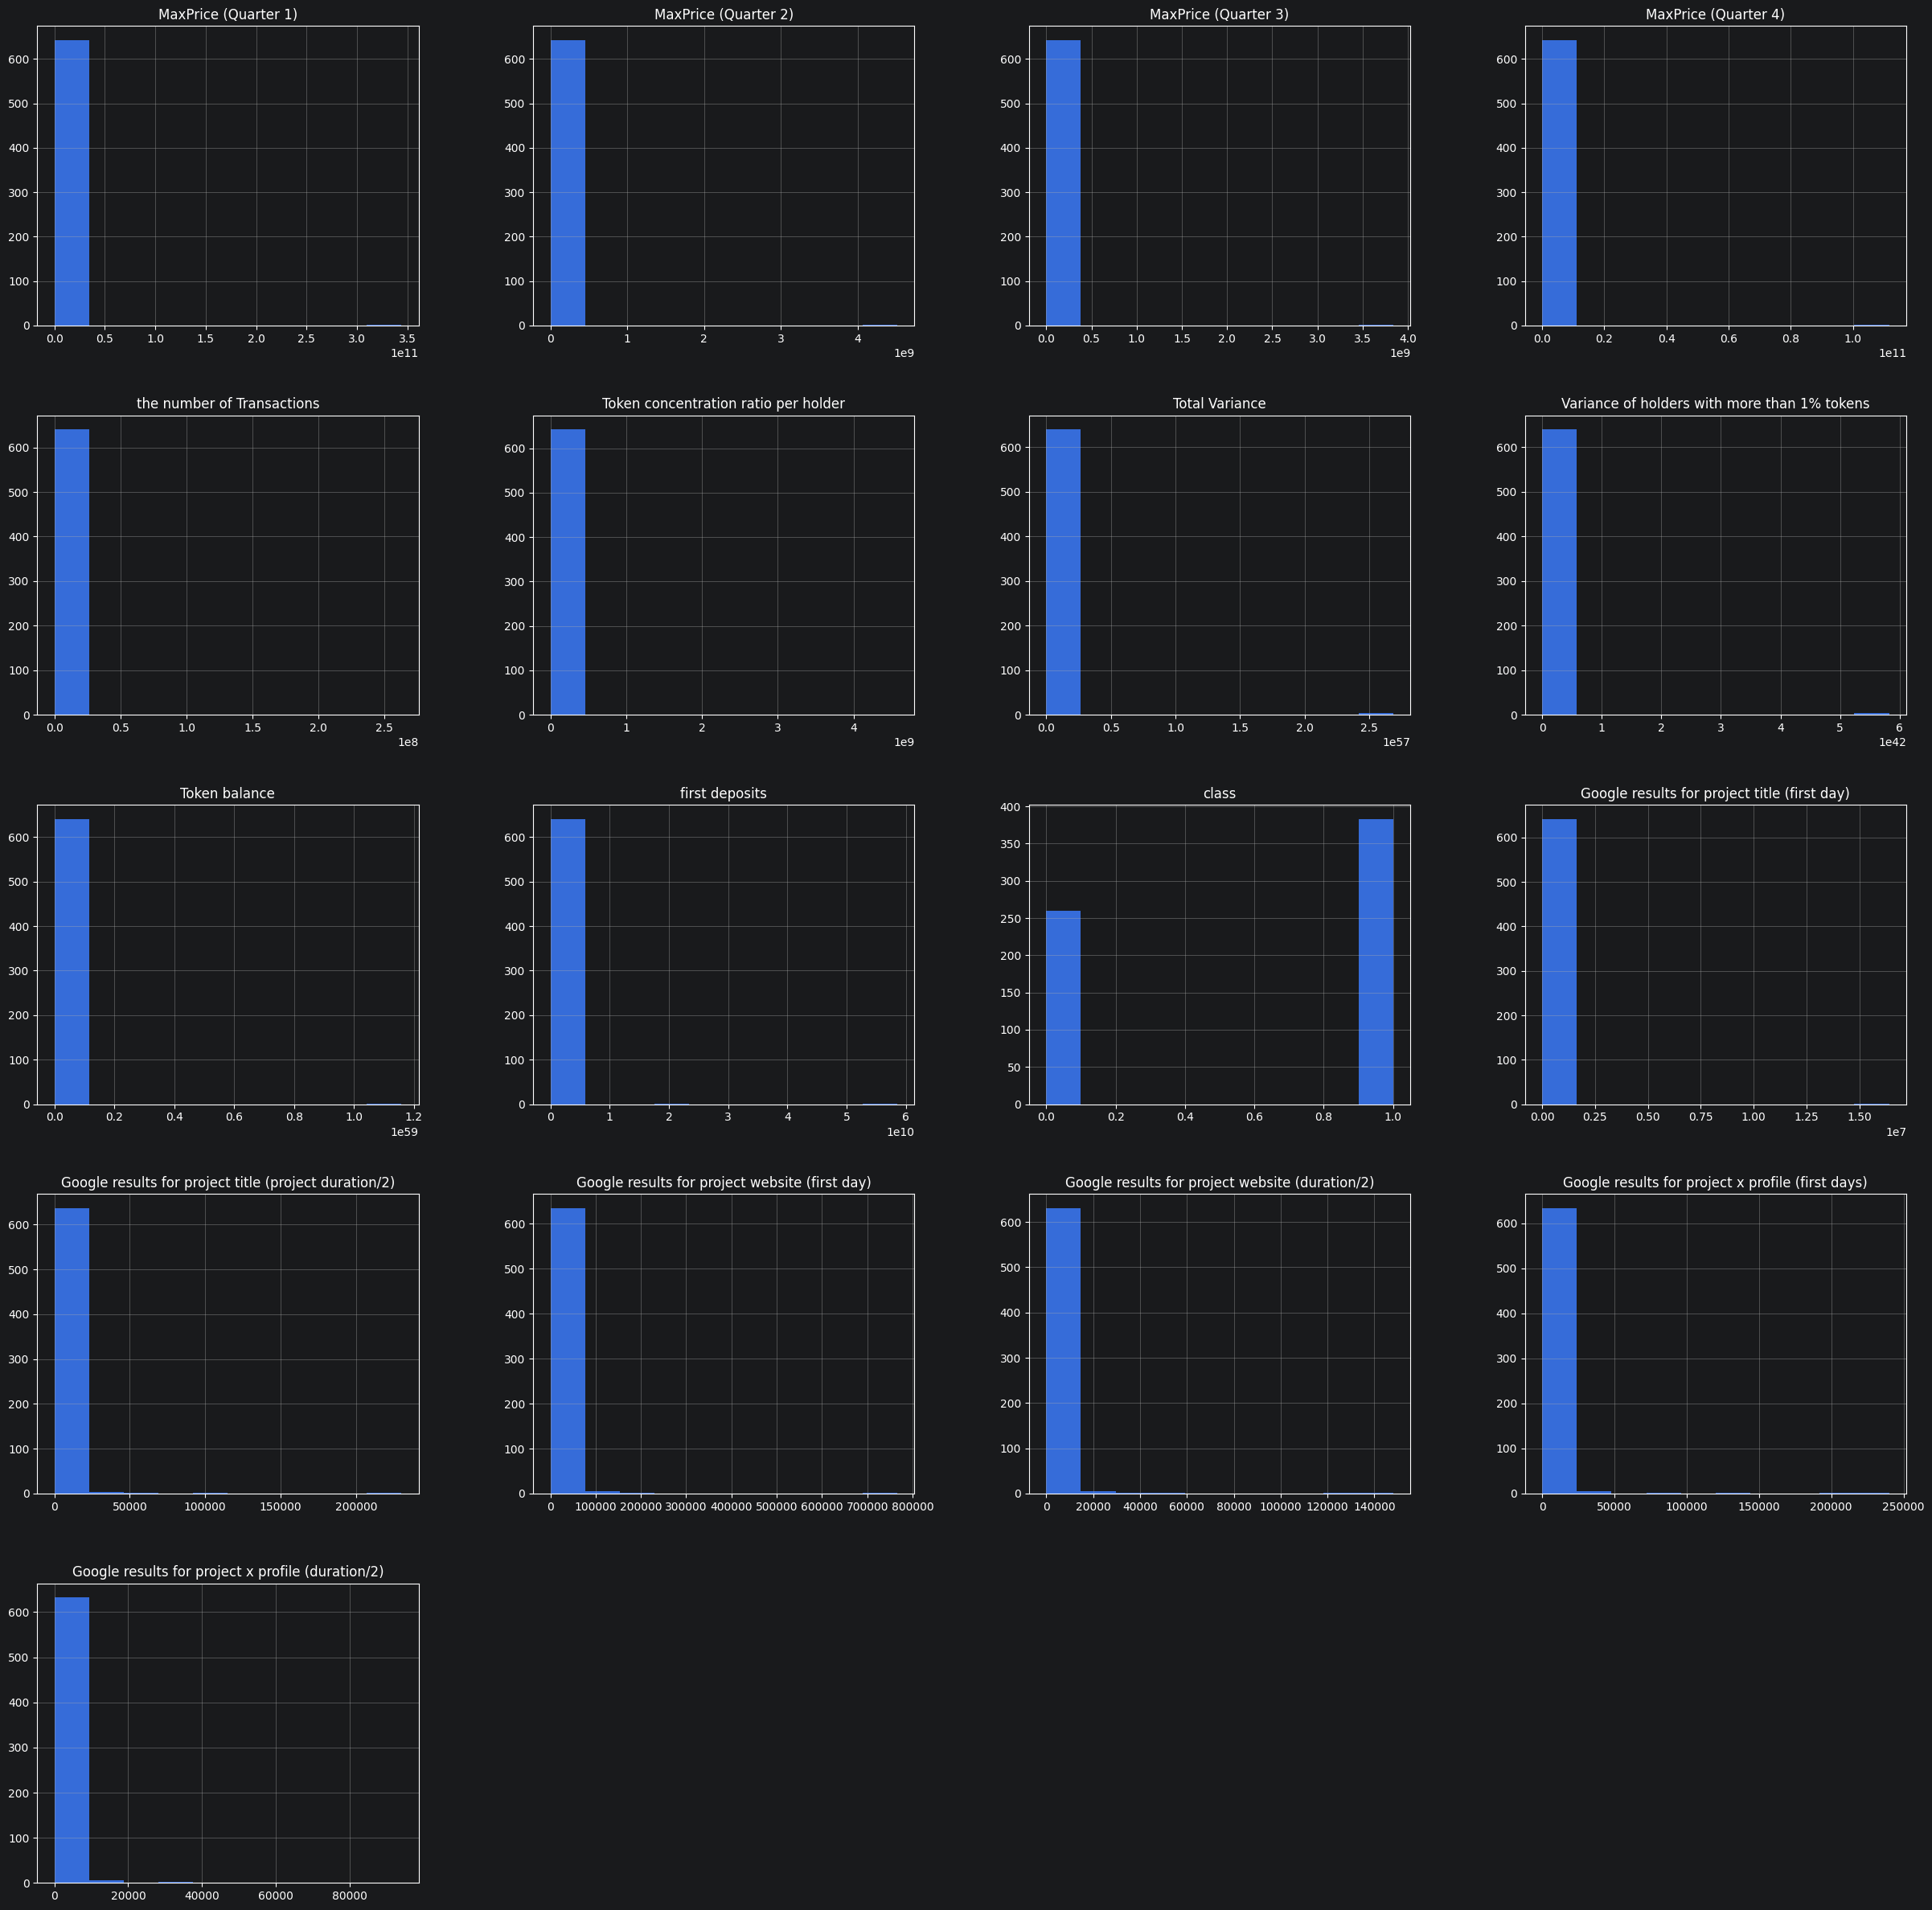

In [20]:
# Histograms

train_set.hist(figsize=[30, 30])
pyplot.show()

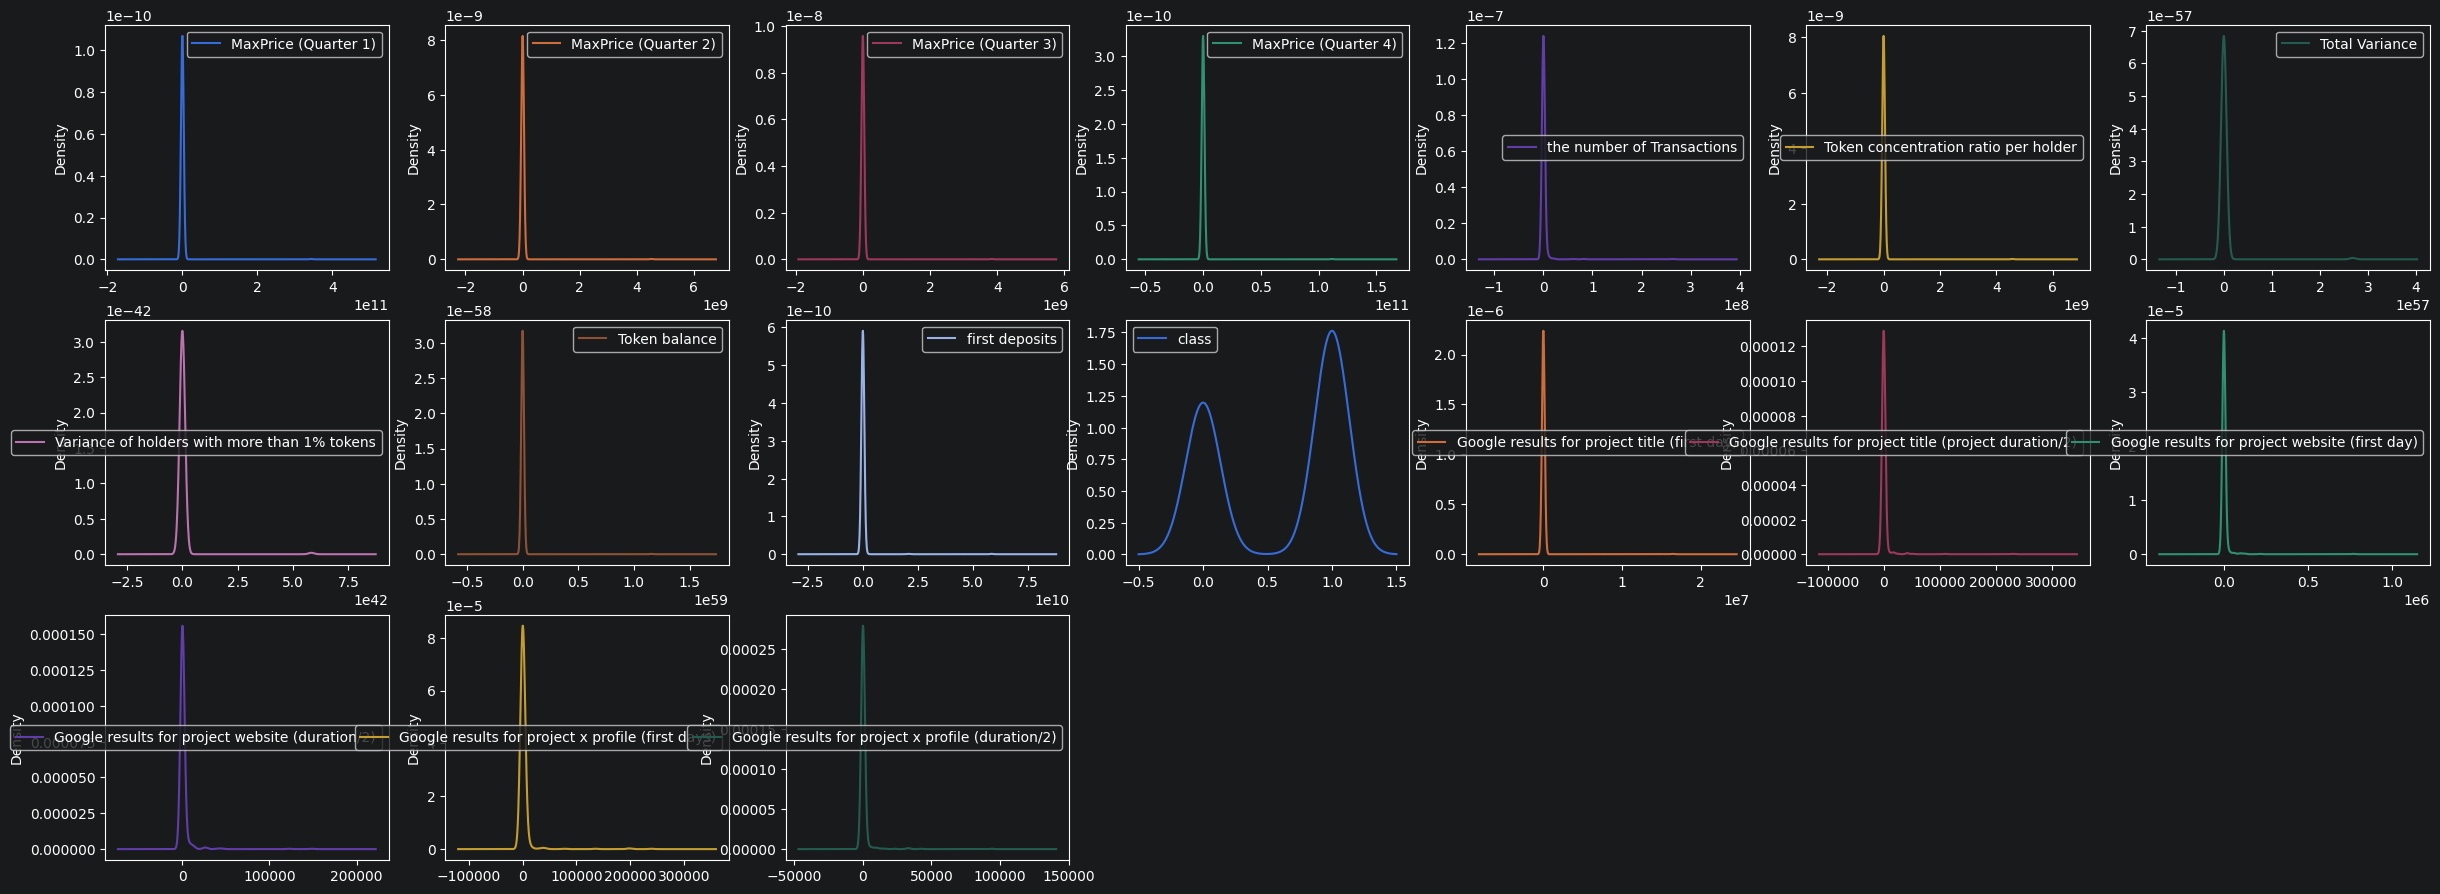

In [21]:
# Density plots

train_set.plot(kind='density', subplots=True, layout=(8,7), sharex=False, sharey=False, figsize=[30, 30])
pyplot.show()

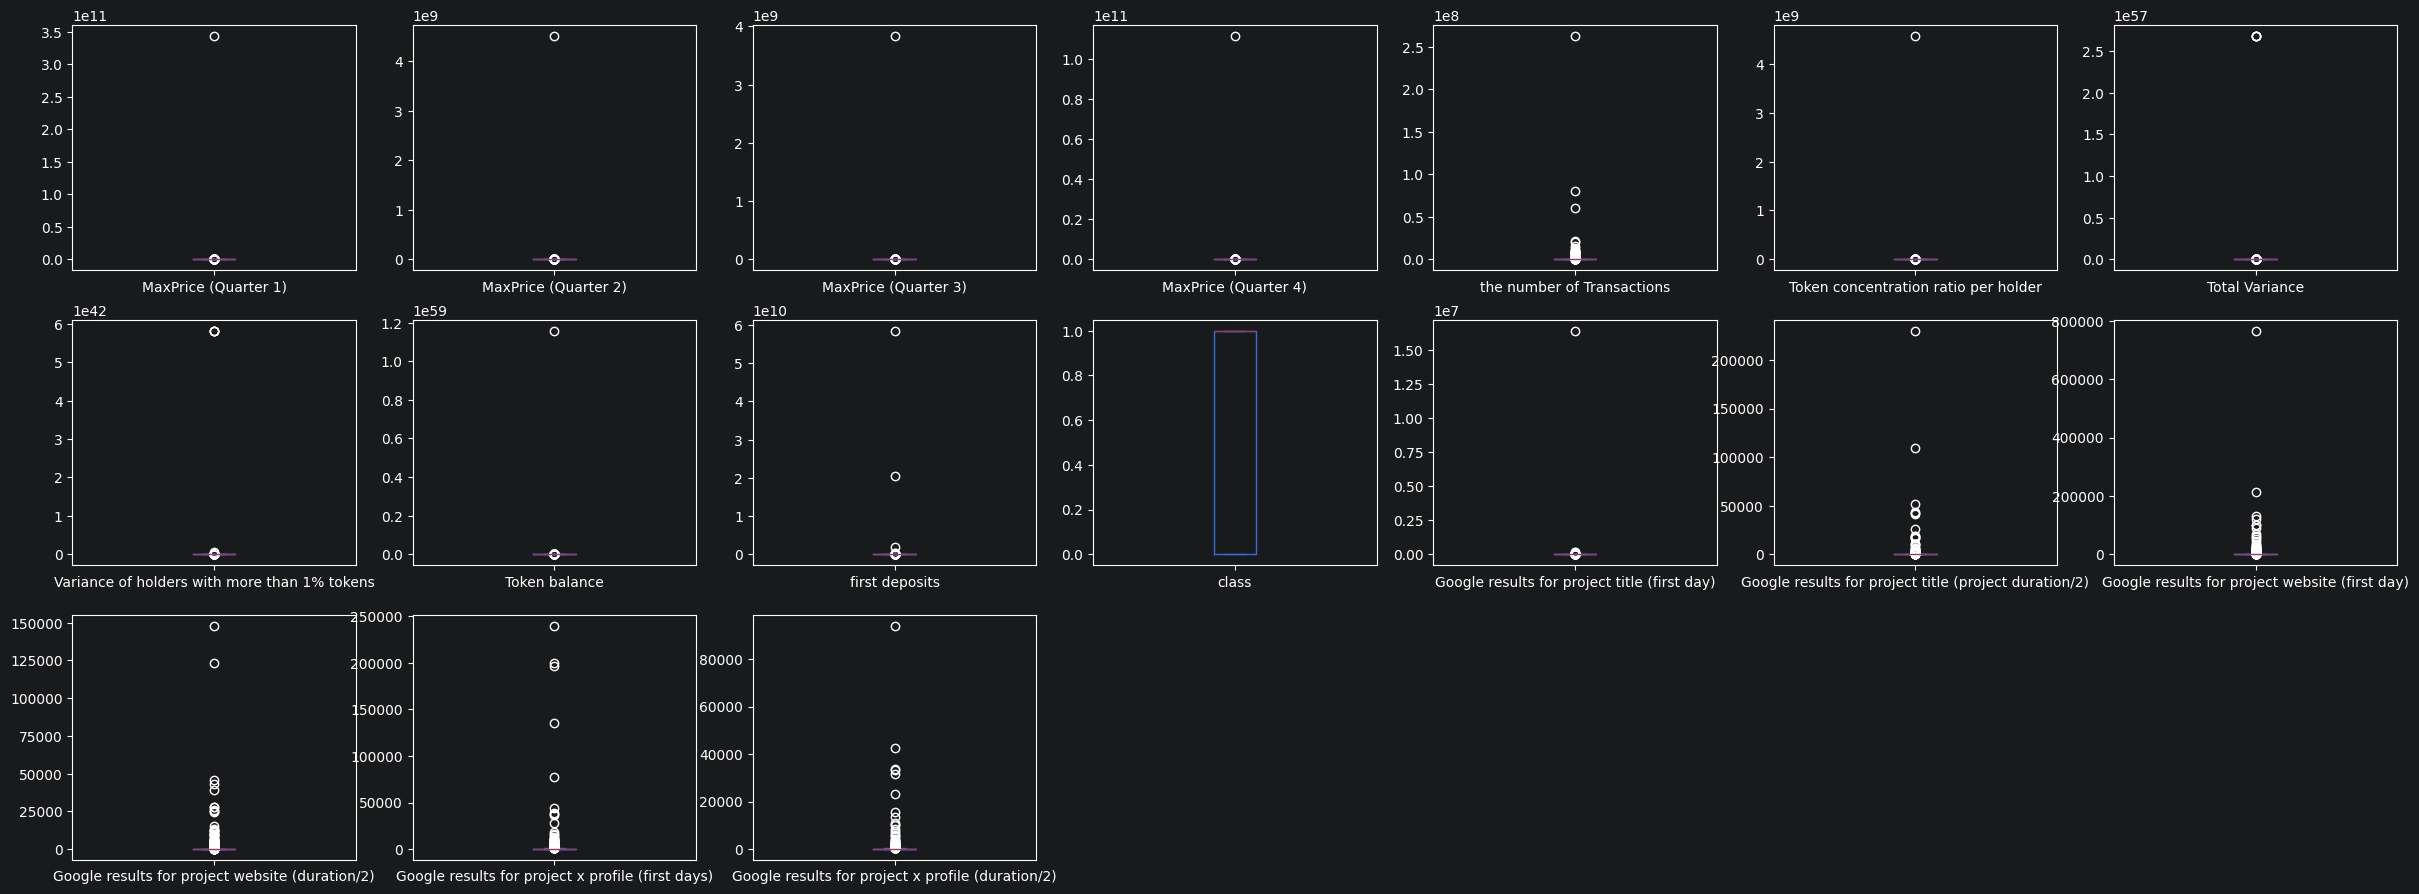

In [22]:
# Box and Whisker Plots

train_set.plot(kind='box', subplots=True, layout=(8,7), sharex=False, sharey=False,figsize=[30, 30])
pyplot.show()

##### Data is extremely skewed and there are extreme outliers, thus, data requires pre-processing.

In [23]:
# Search for correlations of numeric features

correlations = train_set[numeric_cols].corr(method='pearson')

correlations

,MaxPrice (Quarter 1),MaxPrice (Quarter 2),MaxPrice (Quarter 3),MaxPrice (Quarter 4),the number of Transactions,Token concentration ratio per holder,Total Variance,Variance of holders with more than 1% tokens,Token balance,first deposits,class,Google results for project title (first day),Google results for project title (project duration/2),Google results for project website (first day),Google results for project website (duration/2),Google results for project x profile (first days),Google results for project x profile (duration/2)
MaxPrice (Quarter 1),1.000000,1.000000,1.000000,1.000000,-0.003755,-0.001564,-0.003125,-0.003133,-0.001560,0.942955,0.032518,-0.001682,-0.004711,-0.004576,-0.006235,0.021752,0.042208
MaxPrice (Quarter 2),1.000000,1.000000,1.000000,1.000000,-0.003754,-0.001565,-0.003125,-0.003133,-0.001560,0.942955,0.032518,-0.001682,-0.004711,-0.004576,-0.006236,0.021752,0.042208
MaxPrice (Quarter 3),1.000000,1.000000,1.000000,1.000000,-0.003750,-0.001565,-0.003126,-0.003134,-0.001560,0.942955,0.032522,-0.001683,-0.004712,-0.004577,-0.006237,0.021751,0.042207
MaxPrice (Quarter 4),1.000000,1.000000,1.000000,1.000000,-0.003755,-0.001564,-0.003125,-0.003133,-0.001560,0.942955,0.032518,-0.001682,-0.004711,-0.004576,-0.006235,0.021752,0.042208
the number of Transactions,-0.003755,-0.003754,-0.003750,-0.003755,1.000000,-0.000019,-0.007859,-0.007885,-0.003926,-0.004862,-0.111876,-0.003897,-0.008643,-0.005358,-0.005578,0.015751,0.007452
Token concentration ratio per holder,-0.001564,-0.001565,-0.001565,-0.001564,-0.000019,1.000000,-0.003140,-0.003148,-0.001568,-0.002063,-0.048097,-0.001687,-0.004613,-0.004581,-0.006225,-0.005601,-0.005956
Total Variance,-0.003125,-0.003125,-0.003126,-0.003125,-0.007859,-0.003140,1.000000,0.496849,-0.003130,-0.004120,0.065239,-0.003366,-0.009213,-0.009073,-0.012279,-0.011208,-0.011872
Variance of holders with more than 1% tokens,-0.003133,-0.003133,-0.003134,-0.003133,-0.007885,-0.003148,0.496849,1.000000,-0.003138,-0.004131,0.065387,-0.003378,-0.009245,-0.008918,-0.011660,-0.011168,-0.011737
Token balance,-0.001560,-0.001560,-0.001560,-0.001560,-0.003926,-0.001568,-0.003130,-0.003138,1.000000,-0.002057,0.032586,-0.001681,-0.004531,-0.004583,-0.006245,-0.005575,-0.005783
first deposits,0.942955,0.942955,0.942955,0.942955,-0.004862,-0.002063,-0.004120,-0.004131,-0.002057,1.000000,0.042876,-0.002179,-0.005437,-0.005956,-0.008150,0.019035,0.038930


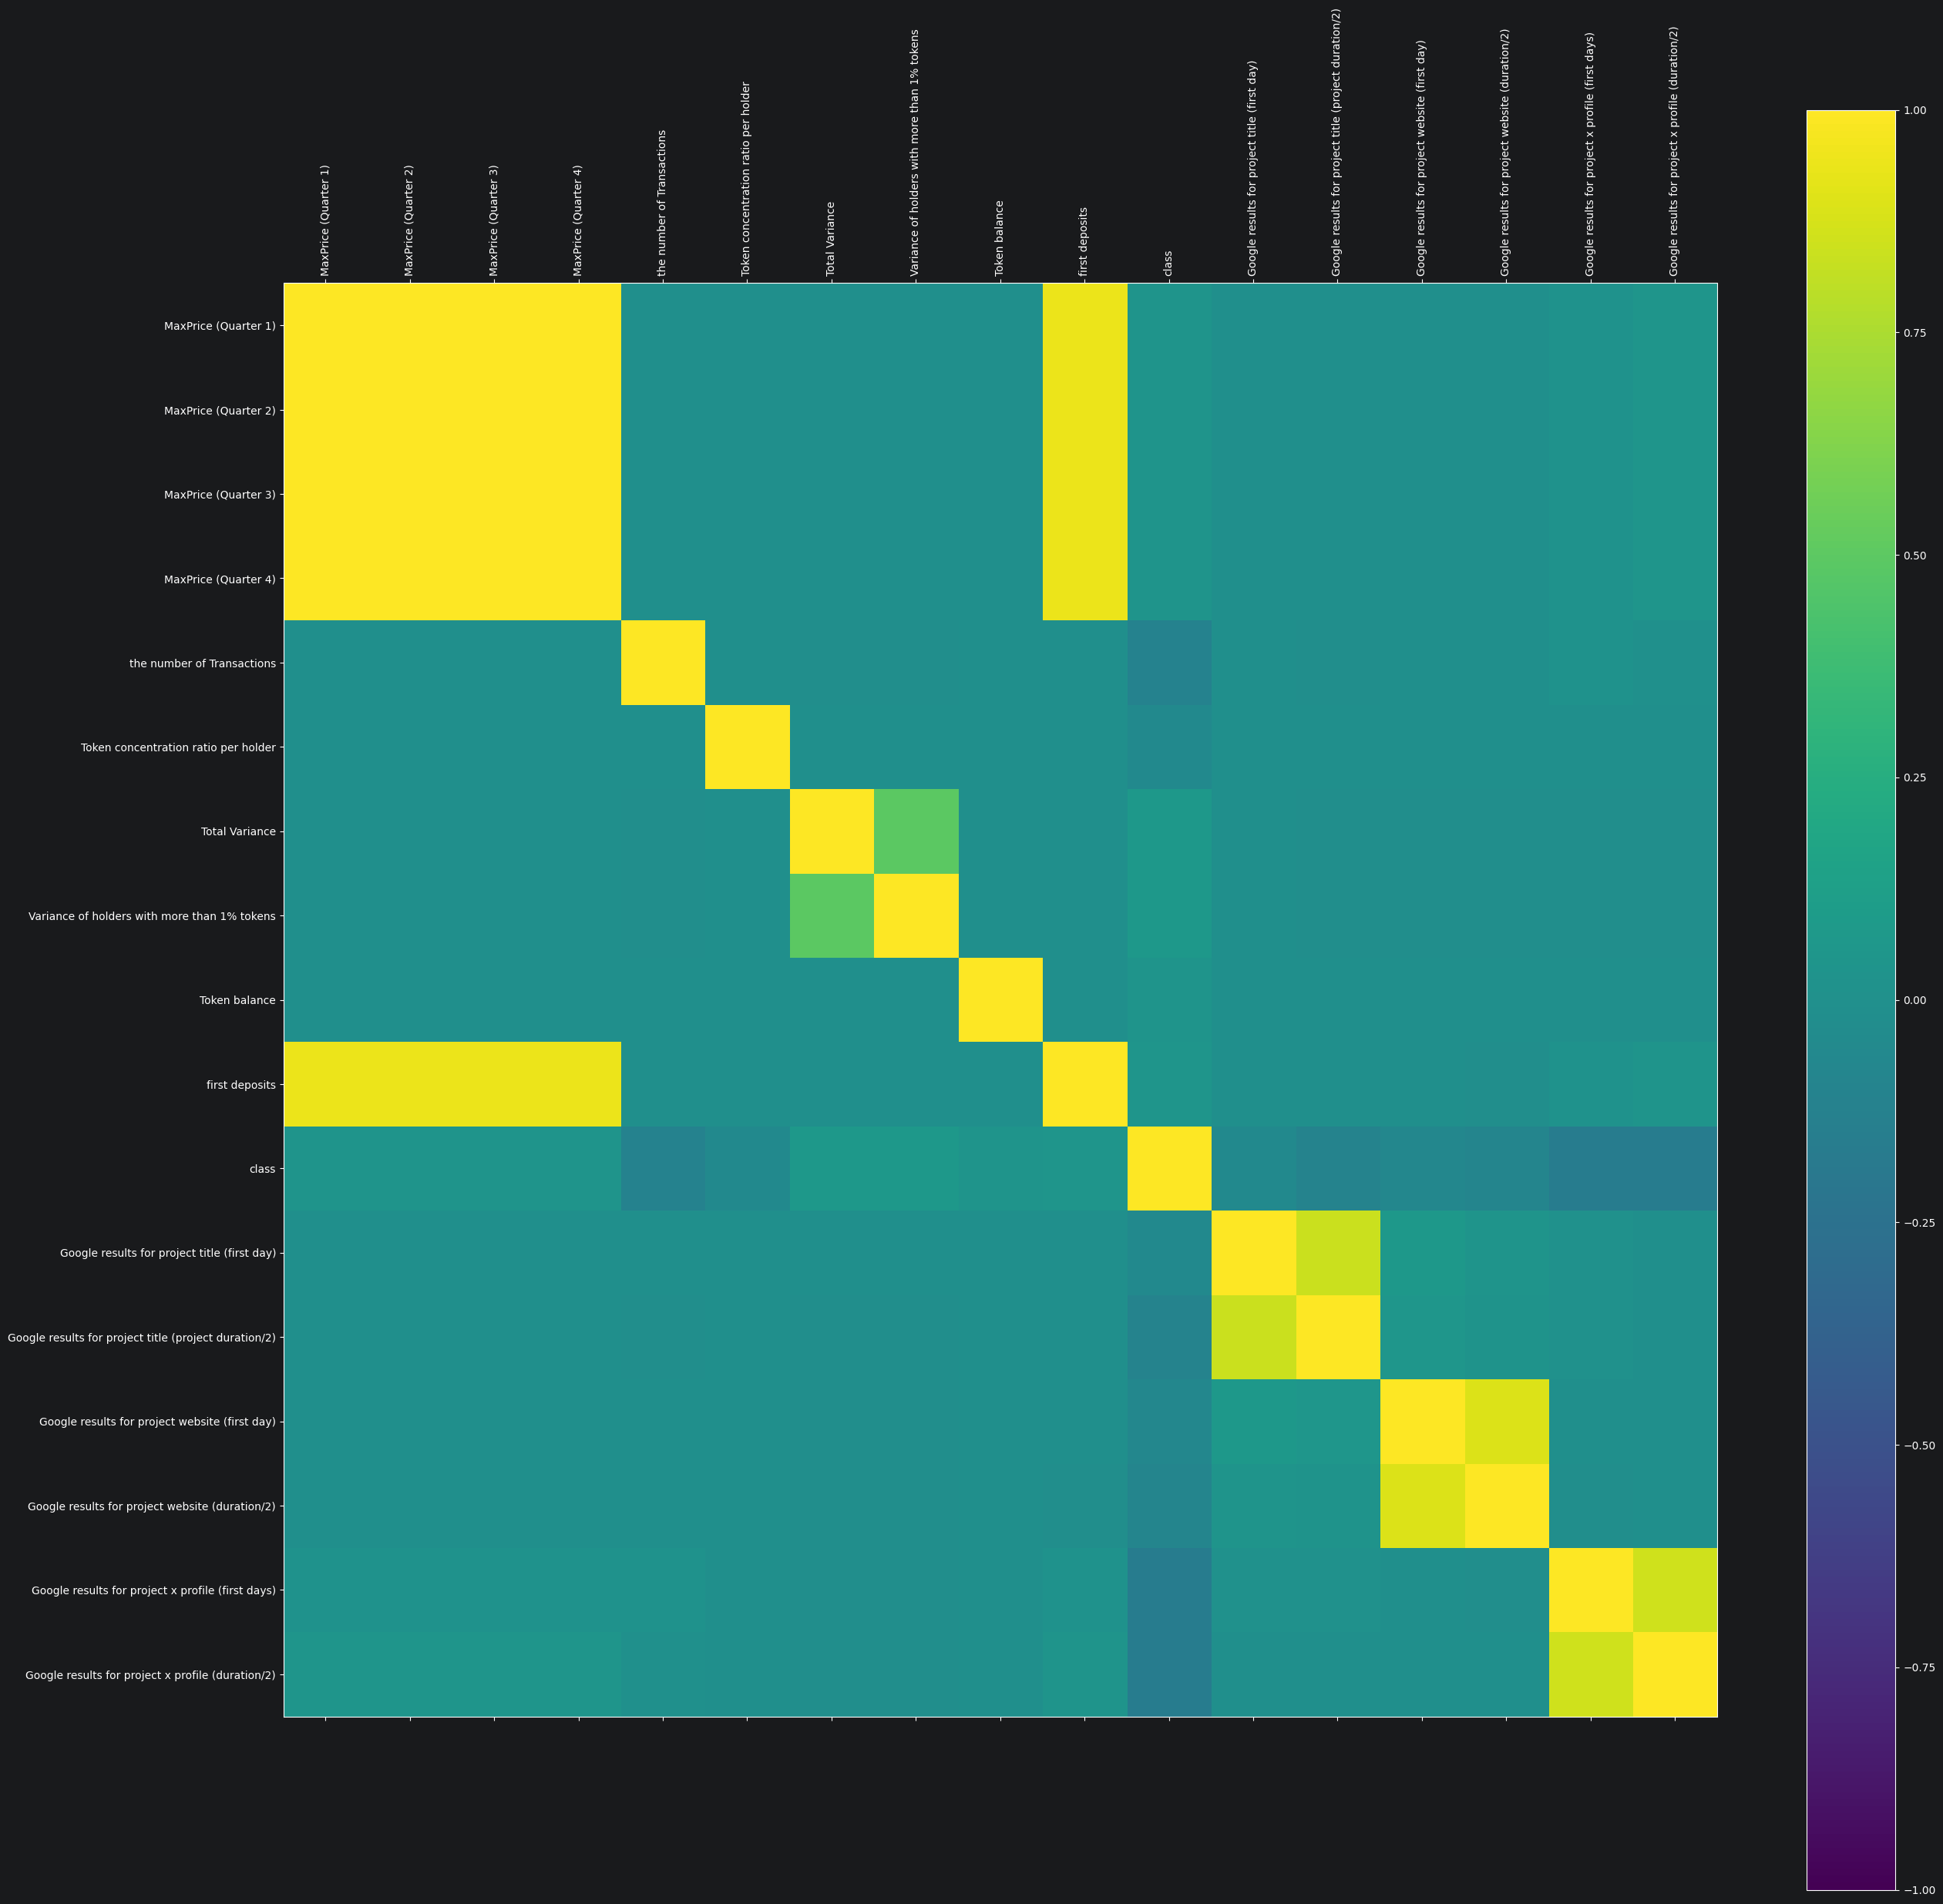

In [24]:
# Correlation Matrix Plot

fig = pyplot.figure(figsize=[30, 30])
ax = fig.add_subplot(111)
cax = ax.matshow(correlations, vmin=-1, vmax=1)
fig.colorbar(cax)

ticks = np.arange(len(correlations.columns))

ax.set_xticks(ticks)
ax.set_yticks(ticks)

short_names = list(train_set[numeric_cols].columns)

ax.set_xticklabels(short_names)
ax.set_yticklabels(short_names)

pyplot.xticks(rotation=90)     # https://www.geeksforgeeks.org/how-to-rotate-x-axis-tick-label-text-in-matplotlib/?ysclid=lxdkiwmkrh456759424

pyplot.show()

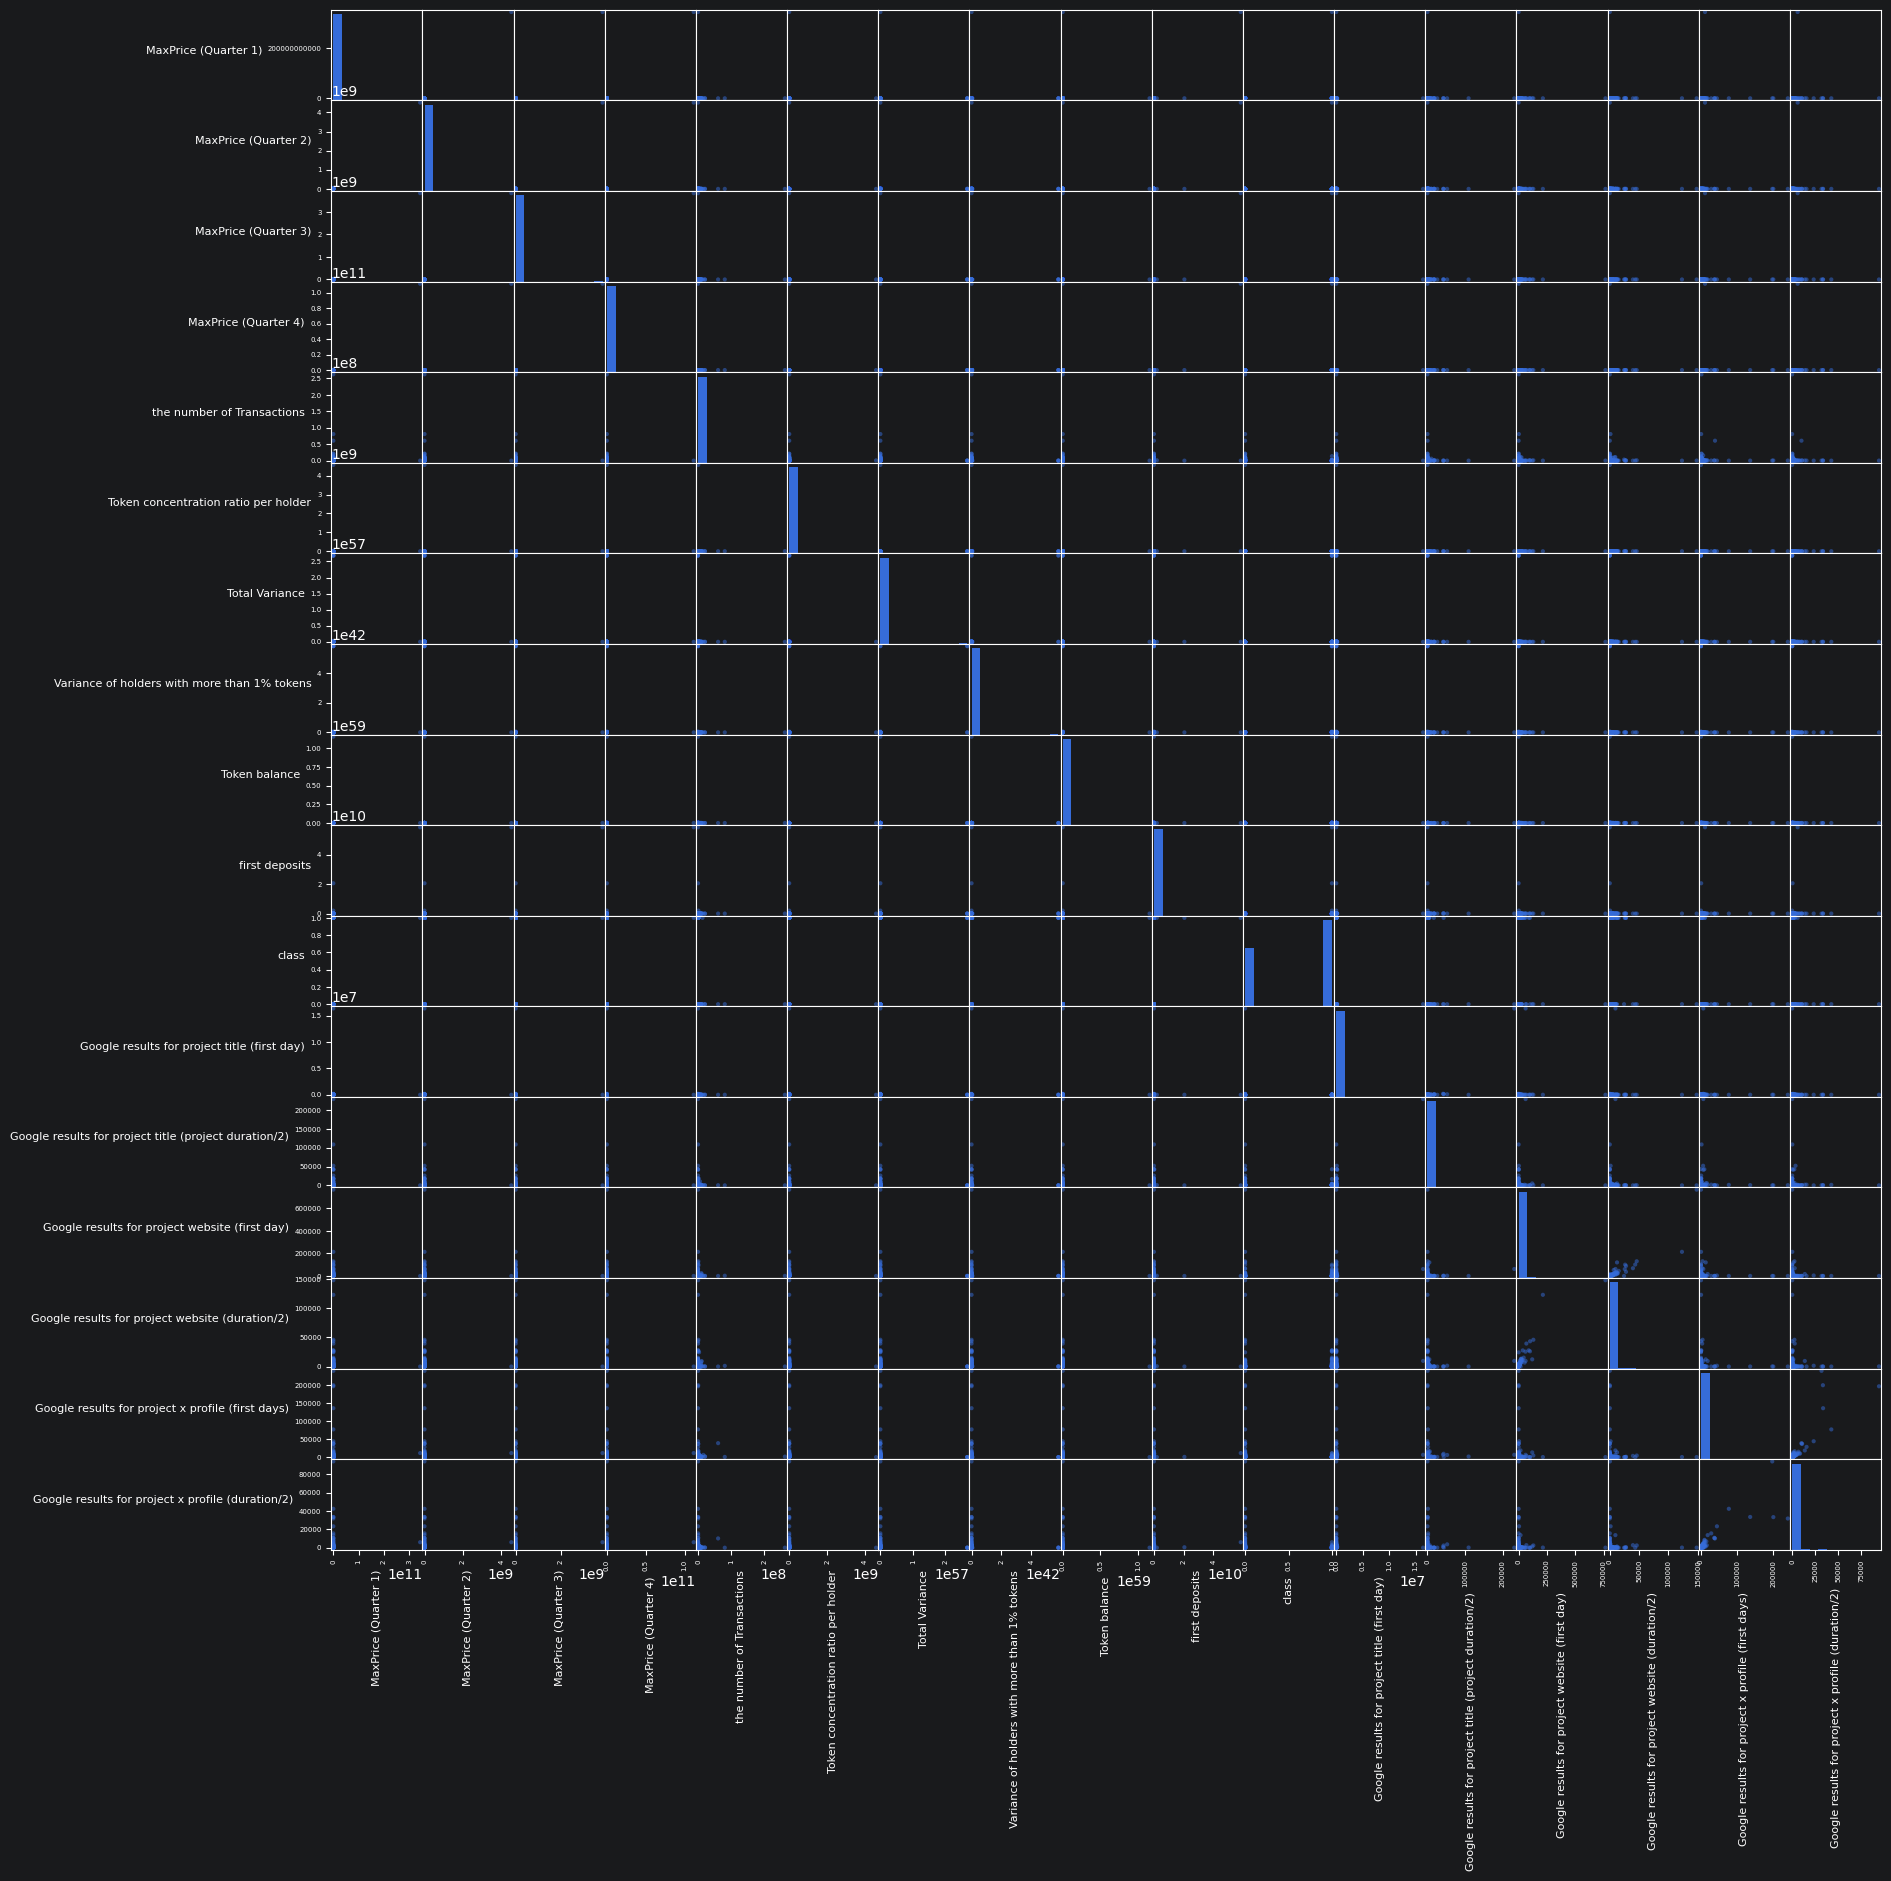

In [25]:
# Scatter plot Matrix

axes = pd.plotting.scatter_matrix(train_set[numeric_cols], figsize=(20, 20))

for ax_row in axes:
    for ax in ax_row:
        ax.xaxis.label.set_rotation(90)
        ax.yaxis.label.set_rotation(0)
        ax.xaxis.label.set_fontsize(8)
        ax.yaxis.label.set_fontsize(8)
        ax.tick_params(axis='both', labelsize=5)

        # Shift y labels left
        ax.yaxis.set_label_position("left")
        ax.yaxis.label.set_horizontalalignment('right')
        ax.yaxis.label.set_x(-0.2)

pyplot.show()

##### Correlation matrix shows strong correlation (almost 1.0) between 'first deposits' and 'Q1'. Manual analysis reveal that 'first deposits' column is likely to be corrupted, since a lot of samples have the same float value here as in 'Q1', which does not make sense (there should be an integer).
##### There is also a strong correlation between price features (Q1, Q2, Q3 and Q4).

##### Based on results of data analysis on raw data, some pre-processing is required. In three following sections different levels of pre-processing will be tried. At first, minimal pre-processing without transformation and scaling will be applied (handling missing values, encode categorical features, clipping extreme outliers). Secondly, heavy skew will be handled using data transformation. Then model specific pre-processing, including scaling where required, will be made for each of intended models.

##### Then the following scenarios will be evaluated:
##### - train all models on minimally pre-processed data (without transformation, but with clipped outliers)
##### - train all models on transformed version of data, but without clipping
##### - train all models on model-specific version of data.

## Minimal pre-processing of data

#### Based on results of data analysis on raw data, some pre-processing is required in order to run most models. For example, extreme outliers with enormous values result in ValueError during model training. In this section, minimal pre-processing will be applied (handling missing values, encoding categorical features, dealing with extreme outliers) in order to make the dataset suitable for model training.

In [26]:
# Remove 'first deposits' manually, since it seems to be corrupted (in majority cases it reproduces Q1 figures, which are prices, not deposits count)
# TODO: consider to replace 'first deposits' (number of initial liquidity deposit events)??

for data_set in data_sets:
    data_set.drop(columns=['first deposits'], inplace=True)

train_set

,MaxPrice (Quarter 1),MaxPrice (Quarter 2),MaxPrice (Quarter 3),MaxPrice (Quarter 4),Blockchain,the number of Transactions,Token concentration ratio per holder,Total Variance,Variance of holders with more than 1% tokens,Token balance,Blockchain Type,class,Google results for project title (first day),Google results for project title (project duration/2),Google results for project website (first day),Google results for project website (duration/2),Google results for project x profile (first days),Google results for project x profile (duration/2)
124,439.6520,66.6710,12.942,9.015,BSC,1272,595,4.020320e+14,4.891000e+08,5.000000e+08,POSA,1,905,479,5580.0,3950.0,293,38
475,326.3300,52.7600,7.070,4.460,BSC,289969,14019,5.862138e+05,3.994789e+09,1.000000e+05,POSA,1,6,4,5.0,5.0,15,467
600,1.9390,6.7500,2.730,13.630,ETH,1289427,83234,1.500177e+12,2.919331e+16,5.324509e+08,POS,0,24400,6120,1.0,0.0,16200,2670
867,285.0000,85.0000,30.800,12.000,ETH,45961,20295,4.774667e+06,4.139753e+09,1.000000e+06,POS,0,264,240,9.0,9.0,64,8
943,0.0220,0.0180,0.007,0.012,BSC,254117,126970,2.307539e+15,7.228413e+18,4.500000e+10,POSA,0,7,4,4.0,2.0,72,42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
783,4.4300,2.1400,0.603,0.870,BSC,4715912,177817,6.750565e+11,6.191921e+15,5.000000e+08,POSA,0,490,177,96.0,9.0,2870,1840
814,21.6000,9.8000,43.000,47.000,ETH,800364,46721,1.514340e+11,8.409678e+07,1.000000e+08,POS,0,8,8,7.0,2.0,7090,272
436,1.3500,7.3500,0.110,1.820,BSC,225237,31763,1.217061e+09,4.347422e+12,9.972109e+06,POSA,1,7,1,0.0,0.0,10,1
534,0.8256,0.7721,1.270,0.880,ETH,28,23,2.960119e+22,9.562339e+22,1.000000e+12,POS,1,480,100,488.0,367.0,118,84


In [27]:
# Handle missing values (for numeric 'median' is used due to heavy skew, for categorical values 'most frequent' is used)
# SimpleImputer is trained for all numeric and categorical columns (not only for ones with missing values) to be able to handle possible future missing values.

# Based on: Géron, A. "End-to-end Machine Learning Project" in 'Hands-on' machine learning with Scikit-Learn, Keras & Tensorflow. (O'Reilly Media, Inc, 2019) 2nd edition.
# Reference: https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html

from sklearn.impute import SimpleImputer

# Define numeric and categorical columns
numeric_cols = train_set.select_dtypes(include=['number']).columns.tolist()
categorical_cols = train_set.select_dtypes(exclude=['number']).columns.tolist()

# Create inputers and fit to train set
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')
num_imputer.fit(train_set[numeric_cols])
cat_imputer.fit(train_set[categorical_cols])

# Apply to train, test, val sets
for data_set in [train_set, test_set, val_set]:
    data_set[numeric_cols] = num_imputer.transform(data_set[numeric_cols])
    data_set[categorical_cols] = cat_imputer.transform(data_set[categorical_cols])

# Verify it works (no missing values left)
print("\nRemaining missing values per column in train_set:")
print(train_set.isnull().sum())


Remaining missing values per column in train_set:
MaxPrice (Quarter 1)                                     0
MaxPrice (Quarter 2)                                     0
MaxPrice (Quarter 3)                                     0
MaxPrice (Quarter 4)                                     0
Blockchain                                               0
the number of Transactions                               0
Token concentration ratio per holder                     0
Total Variance                                           0
Variance of holders with more than 1% tokens             0
Token balance                                            0
Blockchain Type                                          0
class                                                    0
Google results for project title (first day)             0
Google results for project title (project duration/2)    0
Google results for project website (first day)           0
Google results for project website (duration/2)          0
Googl

In [28]:
# Determine unique categories for 'Blockchain' and 'Blockchain Type' columns

print(data_sets[0]['Blockchain'].unique())
print(data_sets[0]['Blockchain Type'].unique())

['BSC' 'ETH' 'POLYGON' 'ARBI']
['POSA' 'POS' 'Fraud Proofs']


In [29]:
# Encode categorical features ('Blockchain', 'Blockchain Type') to make all features numeric.
# OneHotEncoder was chosen, since the number of categories is small (4 for 'Blockchain' and 3 for 'Blockchain Type',
# and OneHotEncoder prevents algorithms to treat close values more similar than distant ones.

# Based on: Based on: Géron, A. "End-to-end Machine Learning Project" in 'Hands-on' machine learning with Scikit-Learn, Keras & Tensorflow. (O'Reilly Media, Inc, 2019) 2nd edition.
# Reference: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html

from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['Blockchain', 'Blockchain Type']
cat_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
cat_encoder.fit(train_set[categorical_cols])

# Apply to each split
for data_set in [train_set, val_set, test_set]:
    cat_array = cat_encoder.transform(data_set[categorical_cols])
    cat_feature_names = cat_encoder.get_feature_names_out(categorical_cols)
    cat_df = pd.DataFrame(cat_array, columns=cat_feature_names, index=data_set.index)

    # Drop original categorical columns
    data_set.drop(columns=categorical_cols, inplace=True)

    # Add encoded columns
    for col in cat_df.columns:
        data_set[col] = cat_df[col]

# Verify it works (all columns are numeric)
print(train_set.dtypes)

MaxPrice (Quarter 1)                                     float64
MaxPrice (Quarter 2)                                     float64
MaxPrice (Quarter 3)                                     float64
MaxPrice (Quarter 4)                                     float64
the number of Transactions                               float64
Token concentration ratio per holder                     float64
Total Variance                                           float64
Variance of holders with more than 1% tokens             float64
Token balance                                            float64
class                                                    float64
Google results for project title (first day)             float64
Google results for project title (project duration/2)    float64
Google results for project website (first day)           float64
Google results for project website (duration/2)          float64
Google results for project x profile (first days)        float64
Google results for projec

In [30]:
# Determine how many extreme outliers are in dataset
# Several numeric features contains extreme values like 10ˆ40 or 10ˆ60, that cannot be handled by estimators and produce an error (Input X contains infinity or a value too large for dtype('float32').

# Reference: https://numpy.org/devdocs/reference/generated/numpy.finfo.html

MAX_F32 = np.finfo(np.float32).max

def count_above_f32(df, name):
    arr = df[numeric_cols].to_numpy()
    above = np.abs(arr) > MAX_F32
    n_above = np.count_nonzero(above)
    total = arr.size

    print(f"{name}: values above float32 max: {n_above} ({n_above / total:.6%})")

count_above_f32(train_set, "train_set")
count_above_f32(val_set,   "val_set")
count_above_f32(test_set,  "test_set")

train_set: values above float32 max: 43 (0.417963%)
val_set: values above float32 max: 4 (0.238095%)
test_set: values above float32 max: 10 (0.258264%)


In [31]:
# Clip extreme values to make data suitable for model training (applied to copies of data, since this step is not relevant
# after transformation (see next section)).
# Clipping is performed for values above float32 datatype capacity.

# Reference: M. Kuhn and K. Johnson, Applied Predictive Modeling. New York, NY, USA: Springer, 2013.

train_minimal = train_set.copy()
val_minimal   = val_set.copy()
test_minimal  = test_set.copy()

numeric_cols_minimal = train_minimal.select_dtypes(include=['number']).columns.tolist()

# Clip everything to float32 capacity
for data_set in [train_minimal, val_minimal, test_minimal]:
    data_set[numeric_cols_minimal] = data_set[numeric_cols_minimal].clip(upper=MAX_F32)

# Verify that no data left that exceeds float32 capacity
for name, data_set in zip(
    ['train_minimal', 'val_minimal', 'test_minimal'],
    [train_minimal, val_minimal, test_minimal]
):
    arr = data_set[numeric_cols_minimal].to_numpy()
    print(f"{name}: any > MAX_F32? {(np.abs(arr) > MAX_F32).any()}")

train_minimal: any > MAX_F32? False
val_minimal: any > MAX_F32? False
test_minimal: any > MAX_F32? False


In [32]:
# Separate features from the target variable for minimally pre-processed dataset
# Extract X and Y from train, test and validation sets after minimal pre-processing

# TODO: reference to AML tutorial

X_train_minimal = train_minimal.drop(columns=['class']).values
Y_train_minimal = train_minimal['class'].values

X_test_minimal = test_minimal.drop(columns=['class']).values
Y_test_minimal = test_minimal['class'].values

X_val_minimal = val_minimal.drop(columns=['class']).values
Y_val_minimal = val_minimal['class'].values

## Data transformation

#### Due to extreme skew, some data transformation will be tried in order to improve performance of models.

#### Data after this step of pre-processing also will be used for plotting to assess the effect of pre-processing on data.

In [33]:
# Transform data to deal with skew
# For columns with heavy skew PowerTransformer is applied

# Reference: M. Kuhn and K. Johnson, Applied Predictive Modeling. New York, NY, USA: Springer, 2013.
# Reference: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PowerTransformer.html

# TODO: to report / notes: log1p transformation has been attempted, resulting in reducing skew to small to moderate values, but several features were still heavily skewed. Thus, PowerTransformer has been applied to find a power that is the most effective in reducing skew for the dataset.

from sklearn.preprocessing import PowerTransformer

skewed_cols = [
    'MaxPrice (Quarter 1)',
    'MaxPrice (Quarter 2)',
    'MaxPrice (Quarter 3)',
    'MaxPrice (Quarter 4)',
    'Total Variance',
    'Variance of holders with more than 1% tokens',
    'Token balance',
    'Token concentration ratio per holder',
    'the number of Transactions',
    'Google results for project title (first day)',
    'Google results for project title (project duration/2)',
    'Google results for project website (first day)',
    'Google results for project website (duration/2)',
    'Google results for project x profile (first days)',
    'Google results for project x profile (duration/2)'
]

# Yeo-Johnson has been chosen, since it handles zeros safely. At this stage, no scaling is applied
pt = PowerTransformer(method='yeo-johnson', standardize=False)
pt.fit(train_set[skewed_cols].astype(float).values)

for data_set in [train_set, val_set, test_set]:
    data_set[skewed_cols] = pt.transform(data_set[skewed_cols].astype(float).values)

# Assess skew after transformation
skew = train_set.skew()
skew

MaxPrice (Quarter 1)                                     0.840737
MaxPrice (Quarter 2)                                     0.978591
MaxPrice (Quarter 3)                                     1.102299
MaxPrice (Quarter 4)                                     1.129794
the number of Transactions                              -0.019291
Token concentration ratio per holder                    -0.002784
Total Variance                                          -0.041653
Variance of holders with more than 1% tokens            -0.086224
Token balance                                           -0.286605
class                                                   -0.390692
Google results for project title (first day)             0.072949
Google results for project title (project duration/2)    0.133960
Google results for project website (first day)           0.259322
Google results for project website (duration/2)          0.324986
Google results for project x profile (first days)        0.054951
Google res

In [34]:
# Make snapshots of moderately pre-processed data for further experimentation

train_transformed = train_set.copy()
test_transformed  = test_set.copy()
val_transformed   = val_set.copy()

In [35]:
# Separate features from the target variable for transformed dataset
# Extract X and Y from train, test and validation sets after transformation

# TODO: reference to AML tutorial

X_train_transformed = train_transformed.drop(columns=['class']).values
Y_train_transformed = train_transformed['class'].values

X_test_transformed = test_transformed.drop(columns=['class']).values
Y_test_transformed = test_transformed['class'].values

X_val_transformed = val_transformed.drop(columns=['class']).values
Y_val_transformed = val_transformed['class'].values

### Visualisation after data transformation

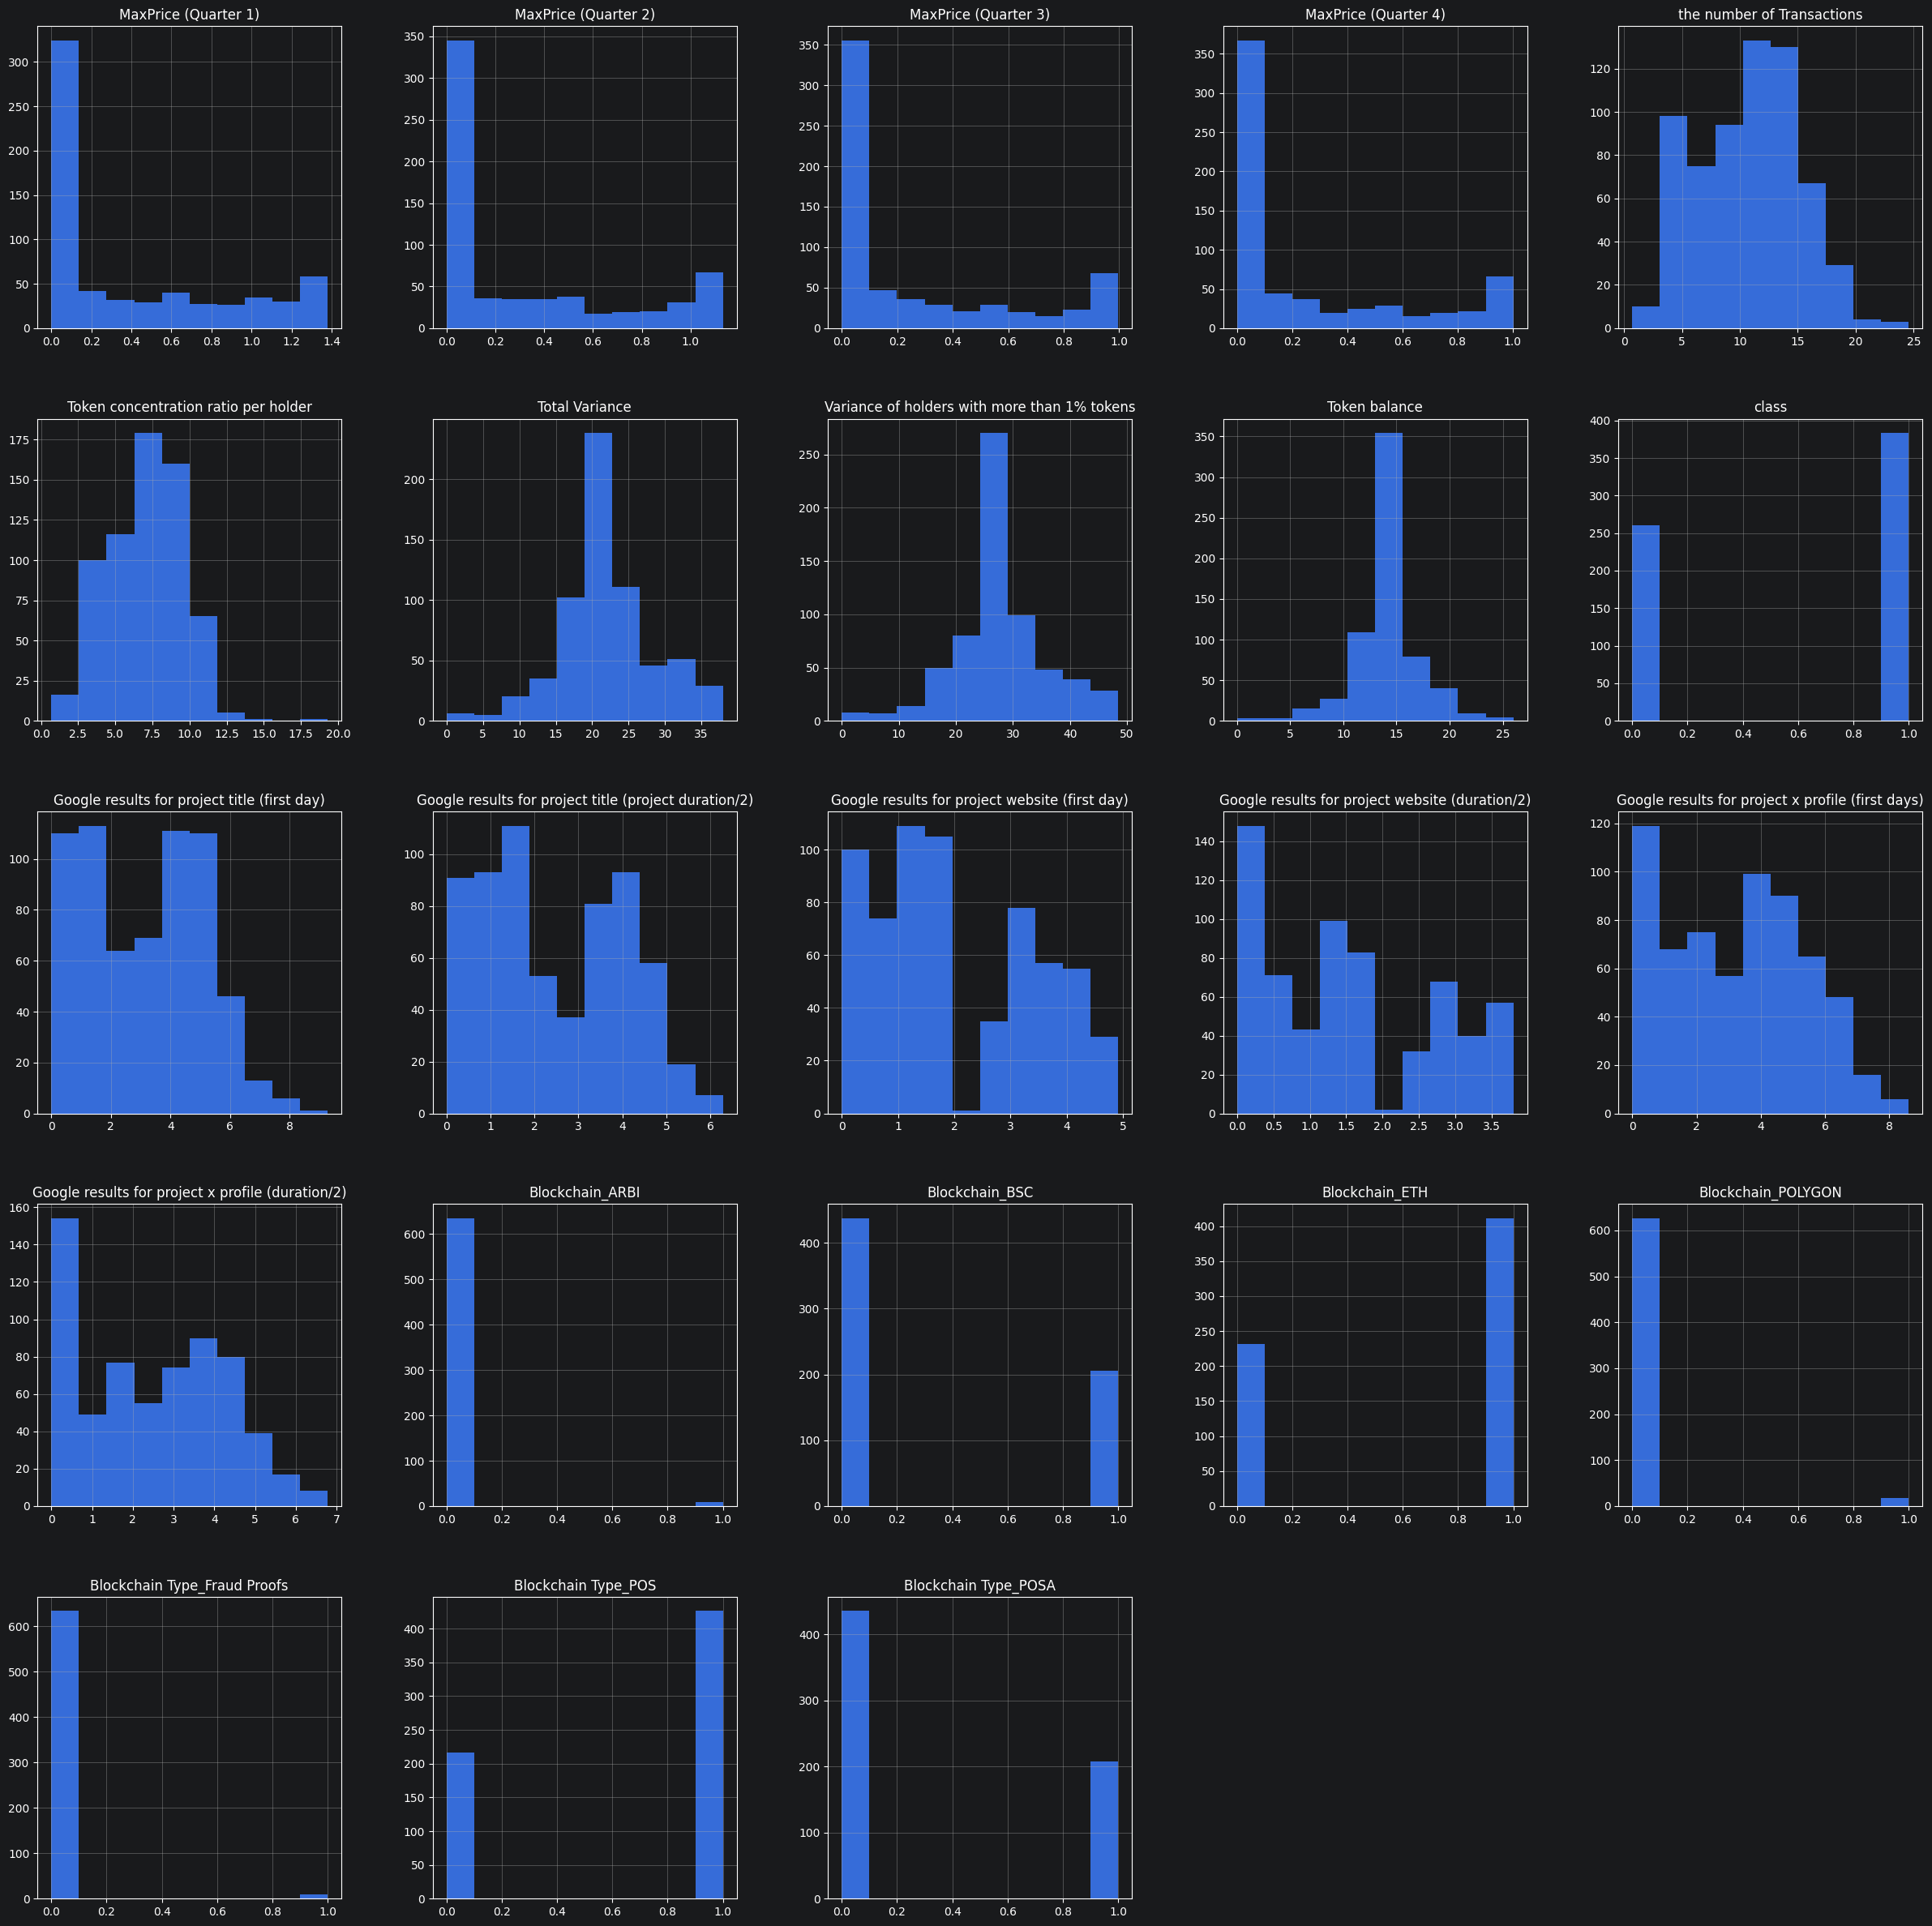

In [36]:
# Histograms after handling skew

train_transformed.hist(figsize=[30, 30])
pyplot.show()

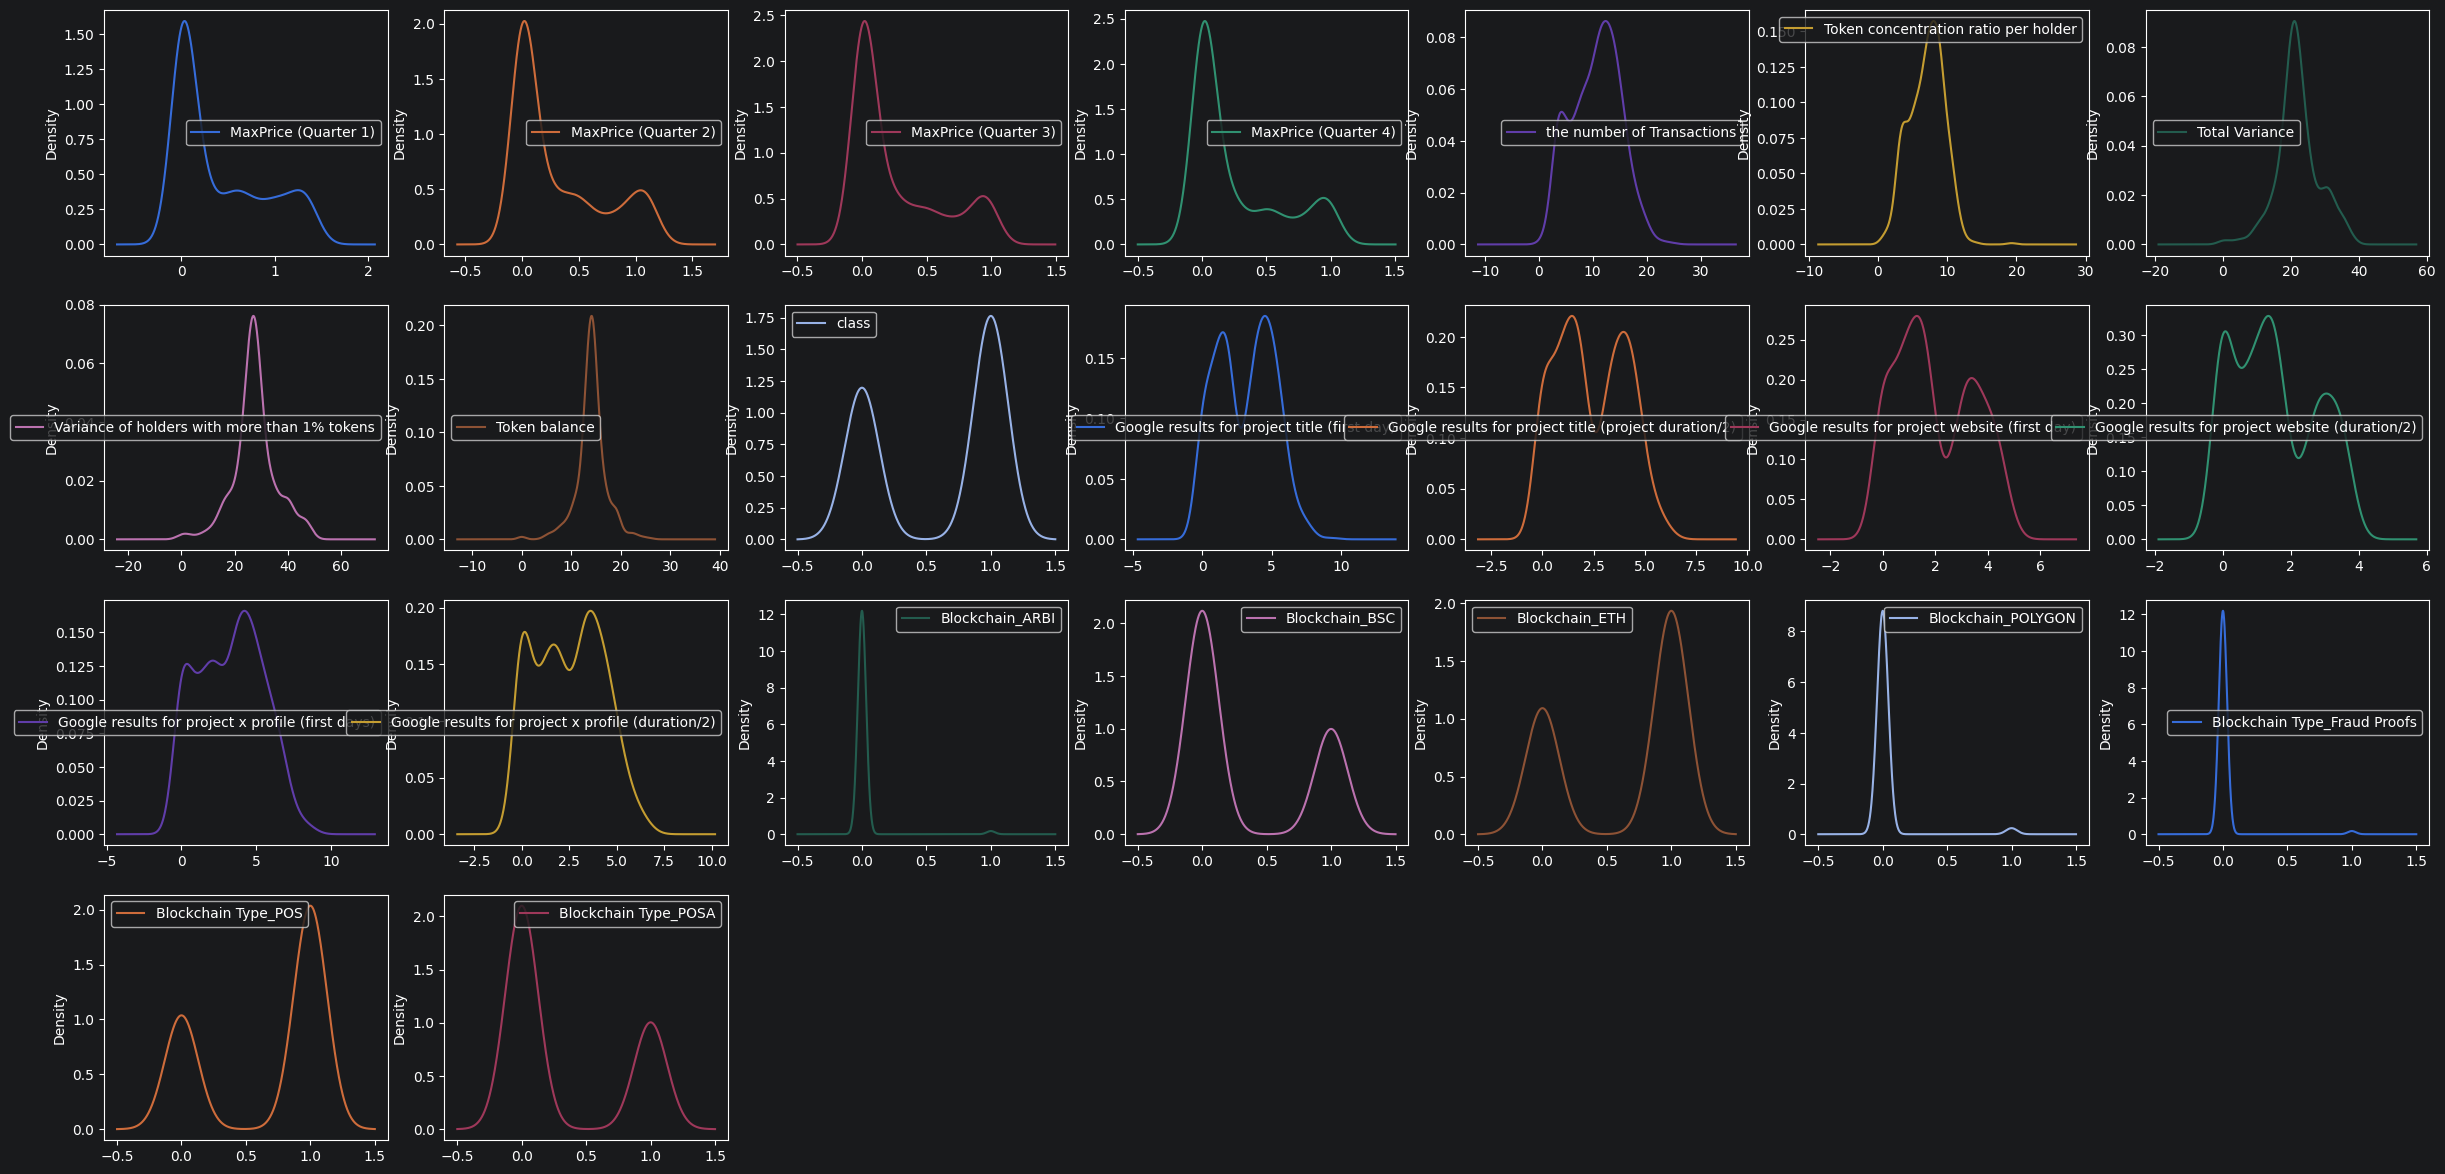

In [37]:
# Density plots after handling skew

train_transformed.plot(kind='density', subplots=True, layout=(8, 7), sharex=False, sharey=False, figsize=[30, 30])
pyplot.show()

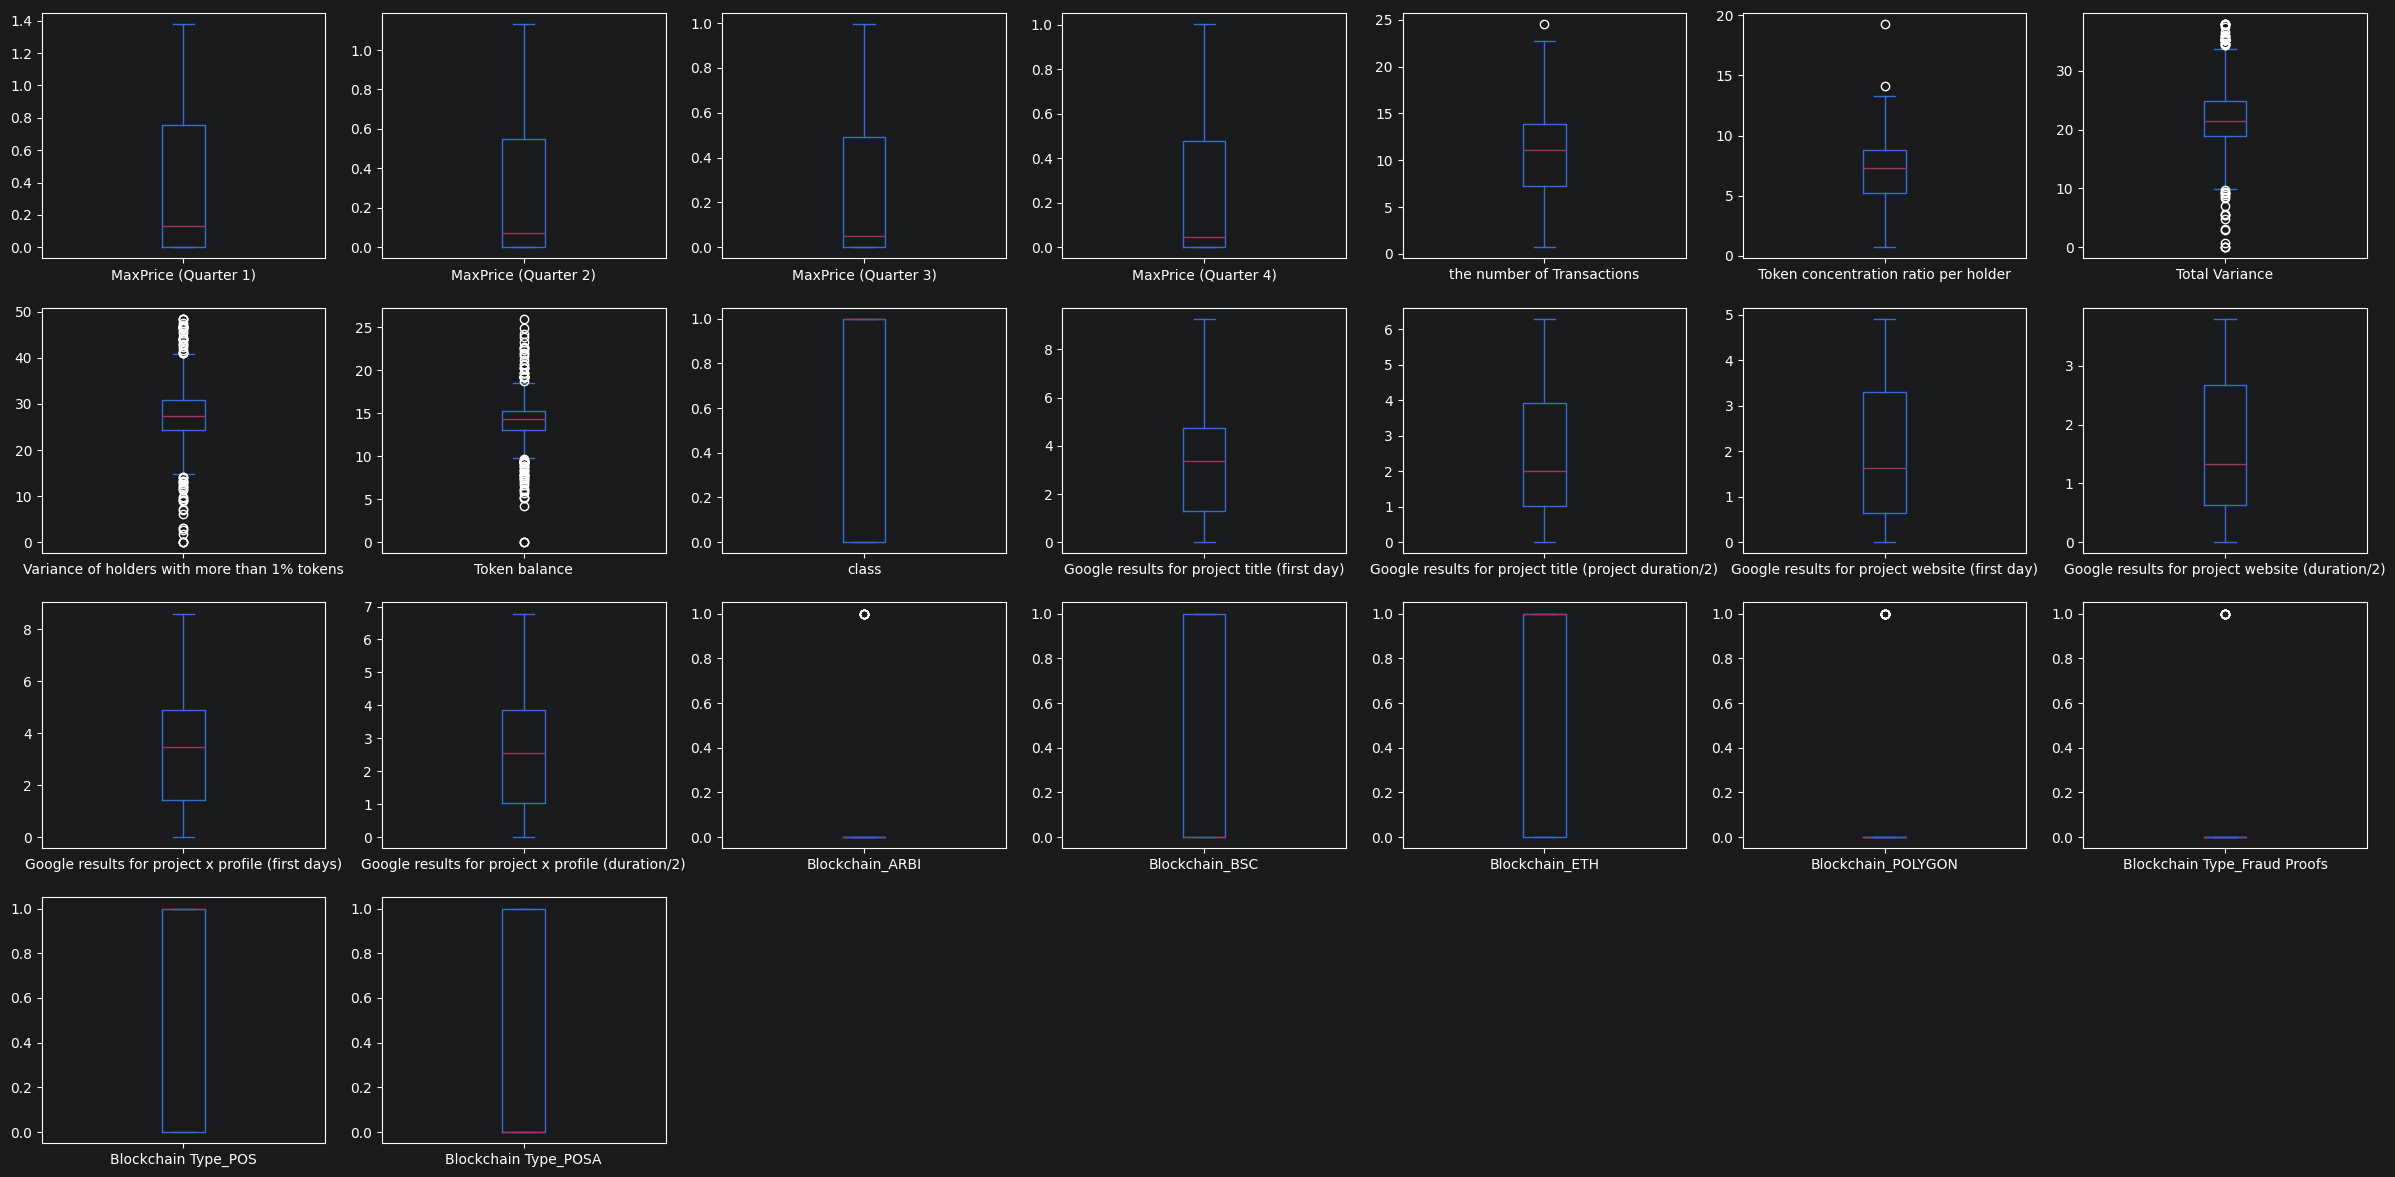

In [38]:
# Box and Whisker Plots after handling skew

train_transformed.plot(kind='box', subplots=True, layout=(8, 7), sharex=False, sharey=False, figsize=[30, 30])
pyplot.show()

In [39]:
# Search for correlations of numeric features after handling skew

correlations = train_transformed[numeric_cols].corr(method='pearson')

correlations

,MaxPrice (Quarter 1),MaxPrice (Quarter 2),MaxPrice (Quarter 3),MaxPrice (Quarter 4),the number of Transactions,Token concentration ratio per holder,Total Variance,Variance of holders with more than 1% tokens,Token balance,class,Google results for project title (first day),Google results for project title (project duration/2),Google results for project website (first day),Google results for project website (duration/2),Google results for project x profile (first days),Google results for project x profile (duration/2)
MaxPrice (Quarter 1),1.000000,0.896516,0.838851,0.764310,0.303892,0.240906,-0.368323,-0.299560,-0.366018,-0.335767,0.228259,0.213969,0.216185,0.141289,0.282998,0.230572
MaxPrice (Quarter 2),0.896516,1.000000,0.930743,0.834411,0.303493,0.242605,-0.370153,-0.310552,-0.374357,-0.337512,0.242971,0.218540,0.209597,0.100996,0.299287,0.223280
MaxPrice (Quarter 3),0.838851,0.930743,1.000000,0.885856,0.278467,0.215697,-0.360344,-0.317905,-0.359111,-0.287988,0.233652,0.203459,0.184083,0.083316,0.275833,0.190023
MaxPrice (Quarter 4),0.764310,0.834411,0.885856,1.000000,0.247738,0.189985,-0.355078,-0.326477,-0.362124,-0.233333,0.236986,0.203276,0.150030,0.065231,0.252618,0.169462
the number of Transactions,0.303892,0.303493,0.278467,0.247738,1.000000,0.859380,-0.332548,-0.172449,-0.060637,-0.591820,0.317036,0.266071,0.167277,0.120430,0.437192,0.395601
Token concentration ratio per holder,0.240906,0.242605,0.215697,0.189985,0.859380,1.000000,-0.260714,-0.093873,0.050163,-0.578888,0.310961,0.259953,0.172480,0.121037,0.444427,0.405387
Total Variance,-0.368323,-0.370153,-0.360344,-0.355078,-0.332548,-0.260714,1.000000,0.821042,0.715659,0.281519,-0.121925,-0.115190,-0.055191,-0.015284,-0.126629,-0.119411
Variance of holders with more than 1% tokens,-0.299560,-0.310552,-0.317905,-0.326477,-0.172449,-0.093873,0.821042,1.000000,0.596124,0.164776,-0.095493,-0.092819,0.007094,0.028971,-0.025378,-0.015972
Token balance,-0.366018,-0.374357,-0.359111,-0.362124,-0.060637,0.050163,0.715659,0.596124,1.000000,0.103332,-0.057226,-0.068868,-0.045361,-0.025053,-0.029987,-0.029090
class,-0.335767,-0.337512,-0.287988,-0.233333,-0.591820,-0.578888,0.281519,0.164776,0.103332,1.000000,-0.313075,-0.305588,-0.178377,-0.104128,-0.550238,-0.455167


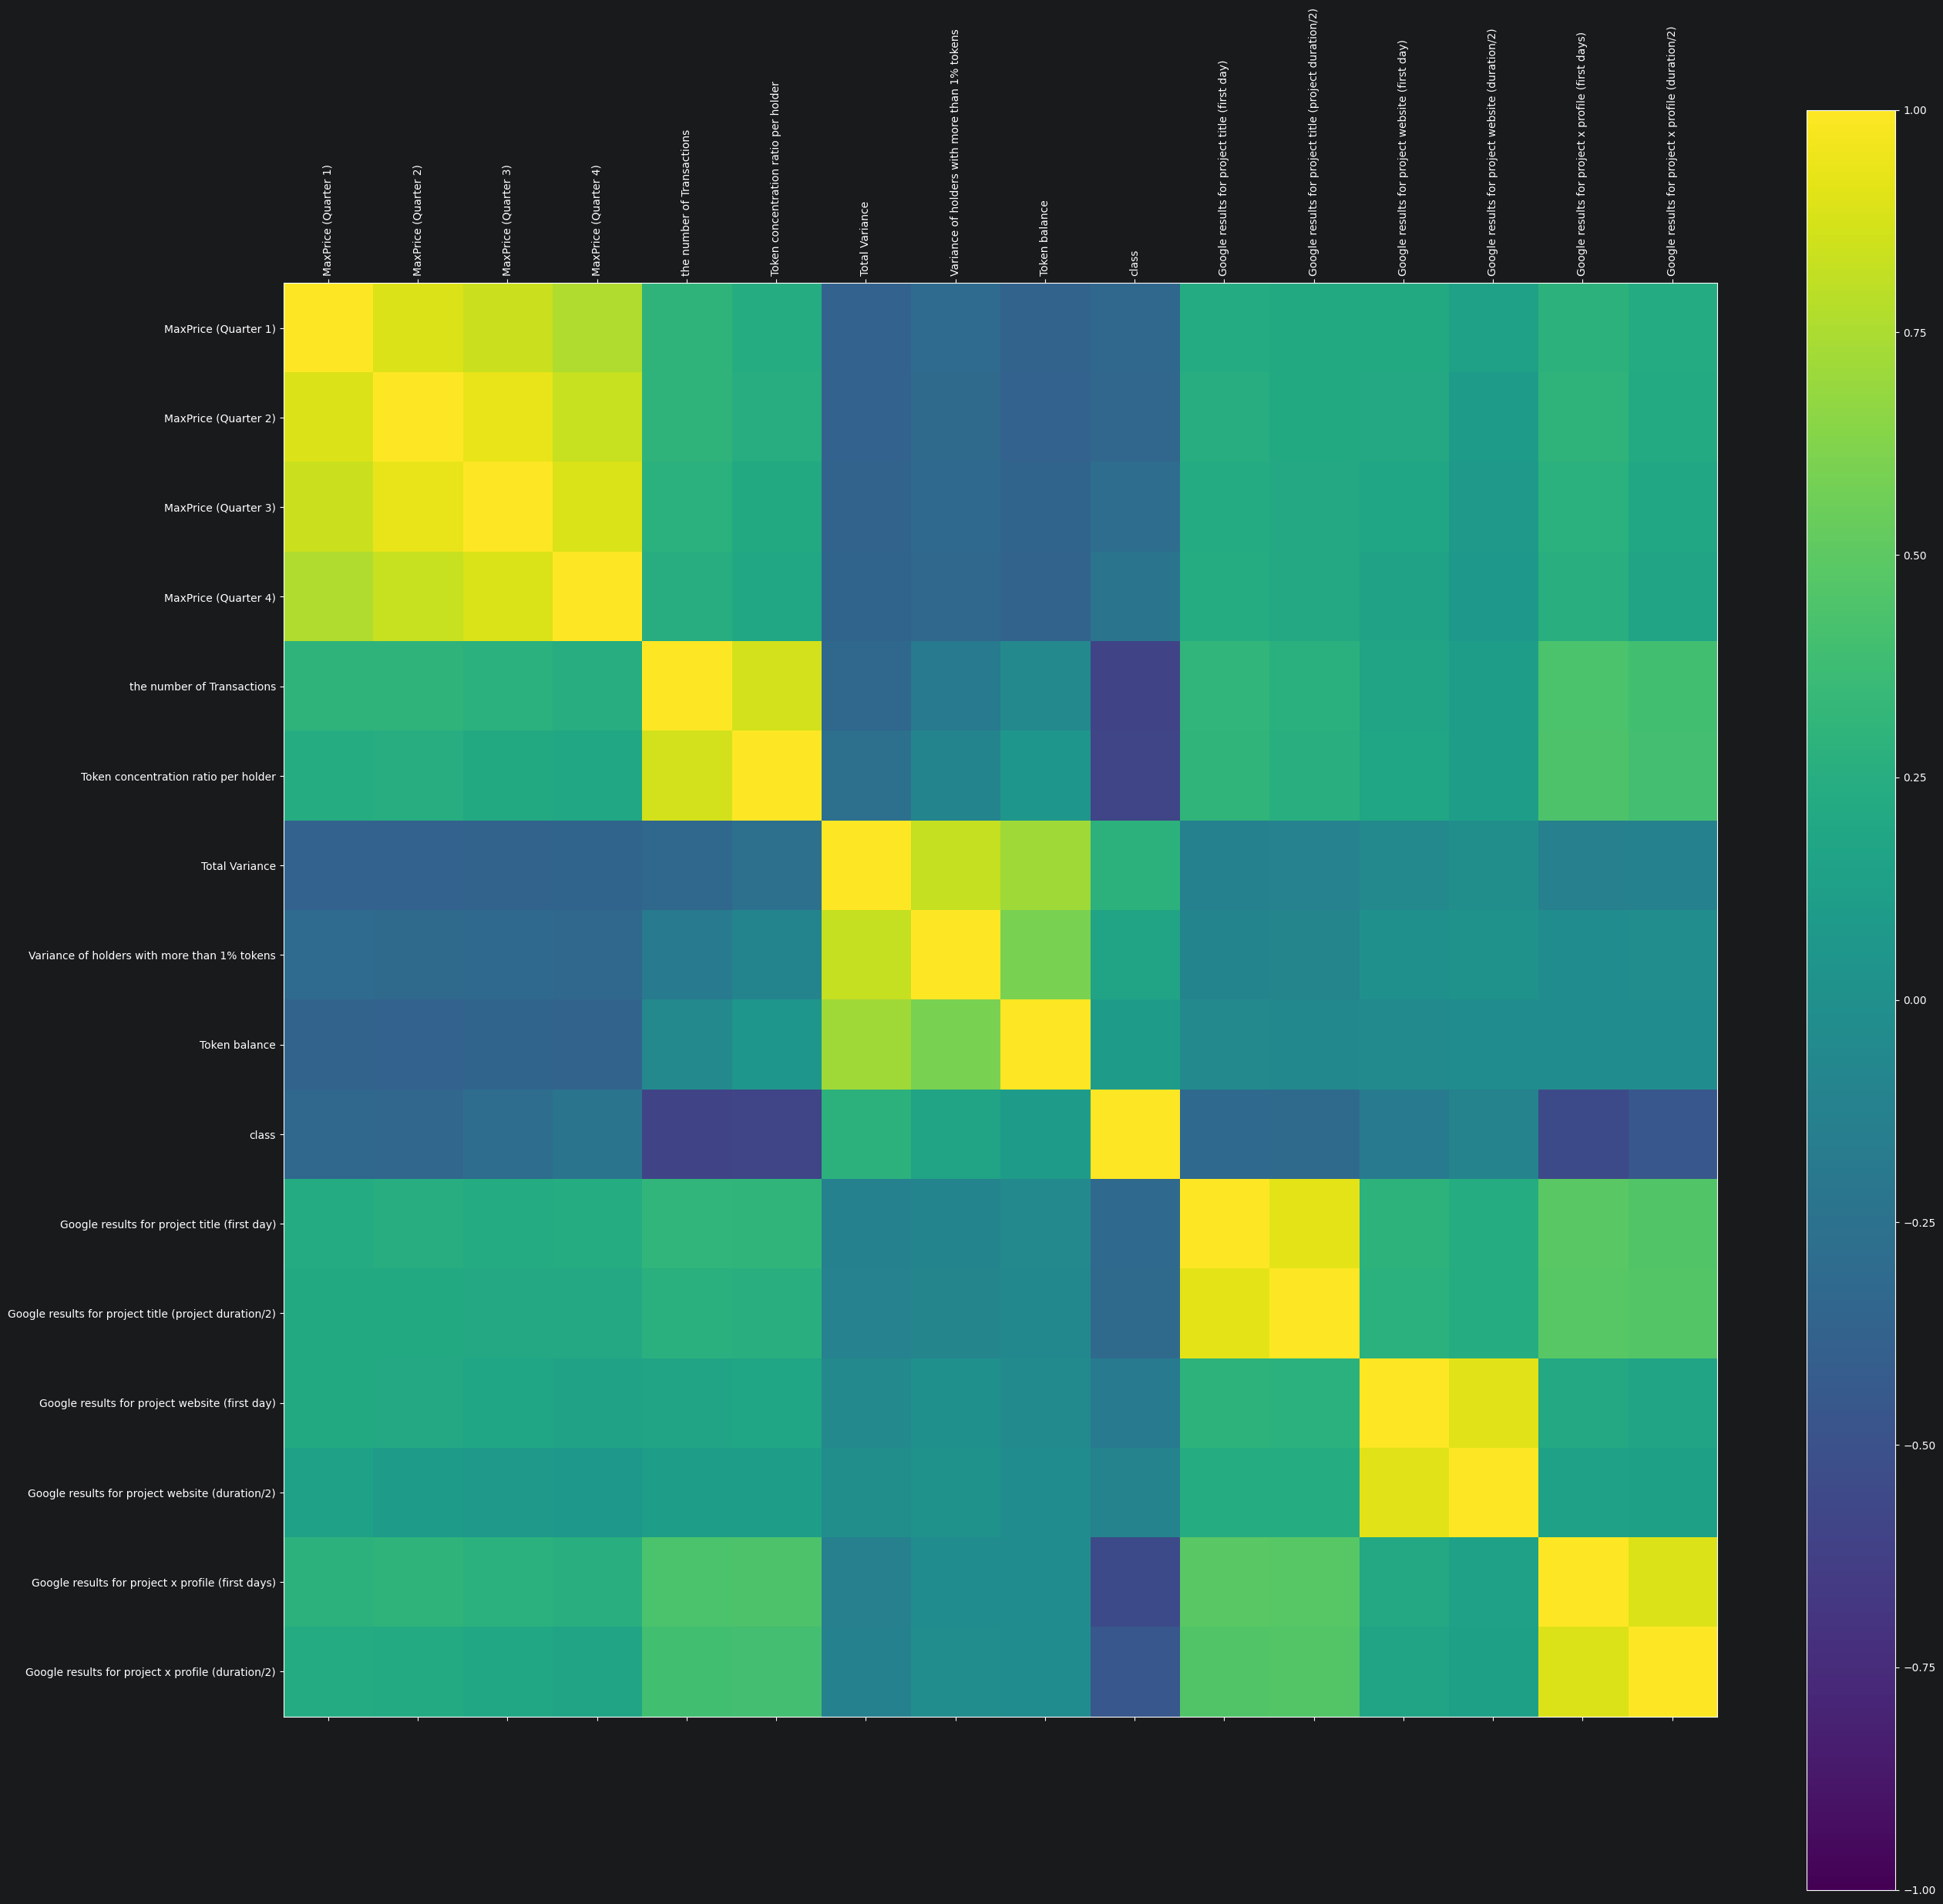

In [40]:
# Correlation Matrix Plot after handling skew

fig = pyplot.figure(figsize=[30, 30])
ax = fig.add_subplot(111)
cax = ax.matshow(correlations, vmin=-1, vmax=1)
fig.colorbar(cax)

numeric_cols = correlations.columns

ticks = np.arange(len(numeric_cols))

ax.set_xticks(ticks)
ax.set_yticks(ticks)

short_names = list(numeric_cols)

ax.set_xticklabels(short_names)
ax.set_yticklabels(short_names)

pyplot.xticks(rotation=90)     # https://www.geeksforgeeks.org/how-to-rotate-x-axis-tick-label-text-in-matplotlib/?ysclid=lxdkiwmkrh456759424

pyplot.show()

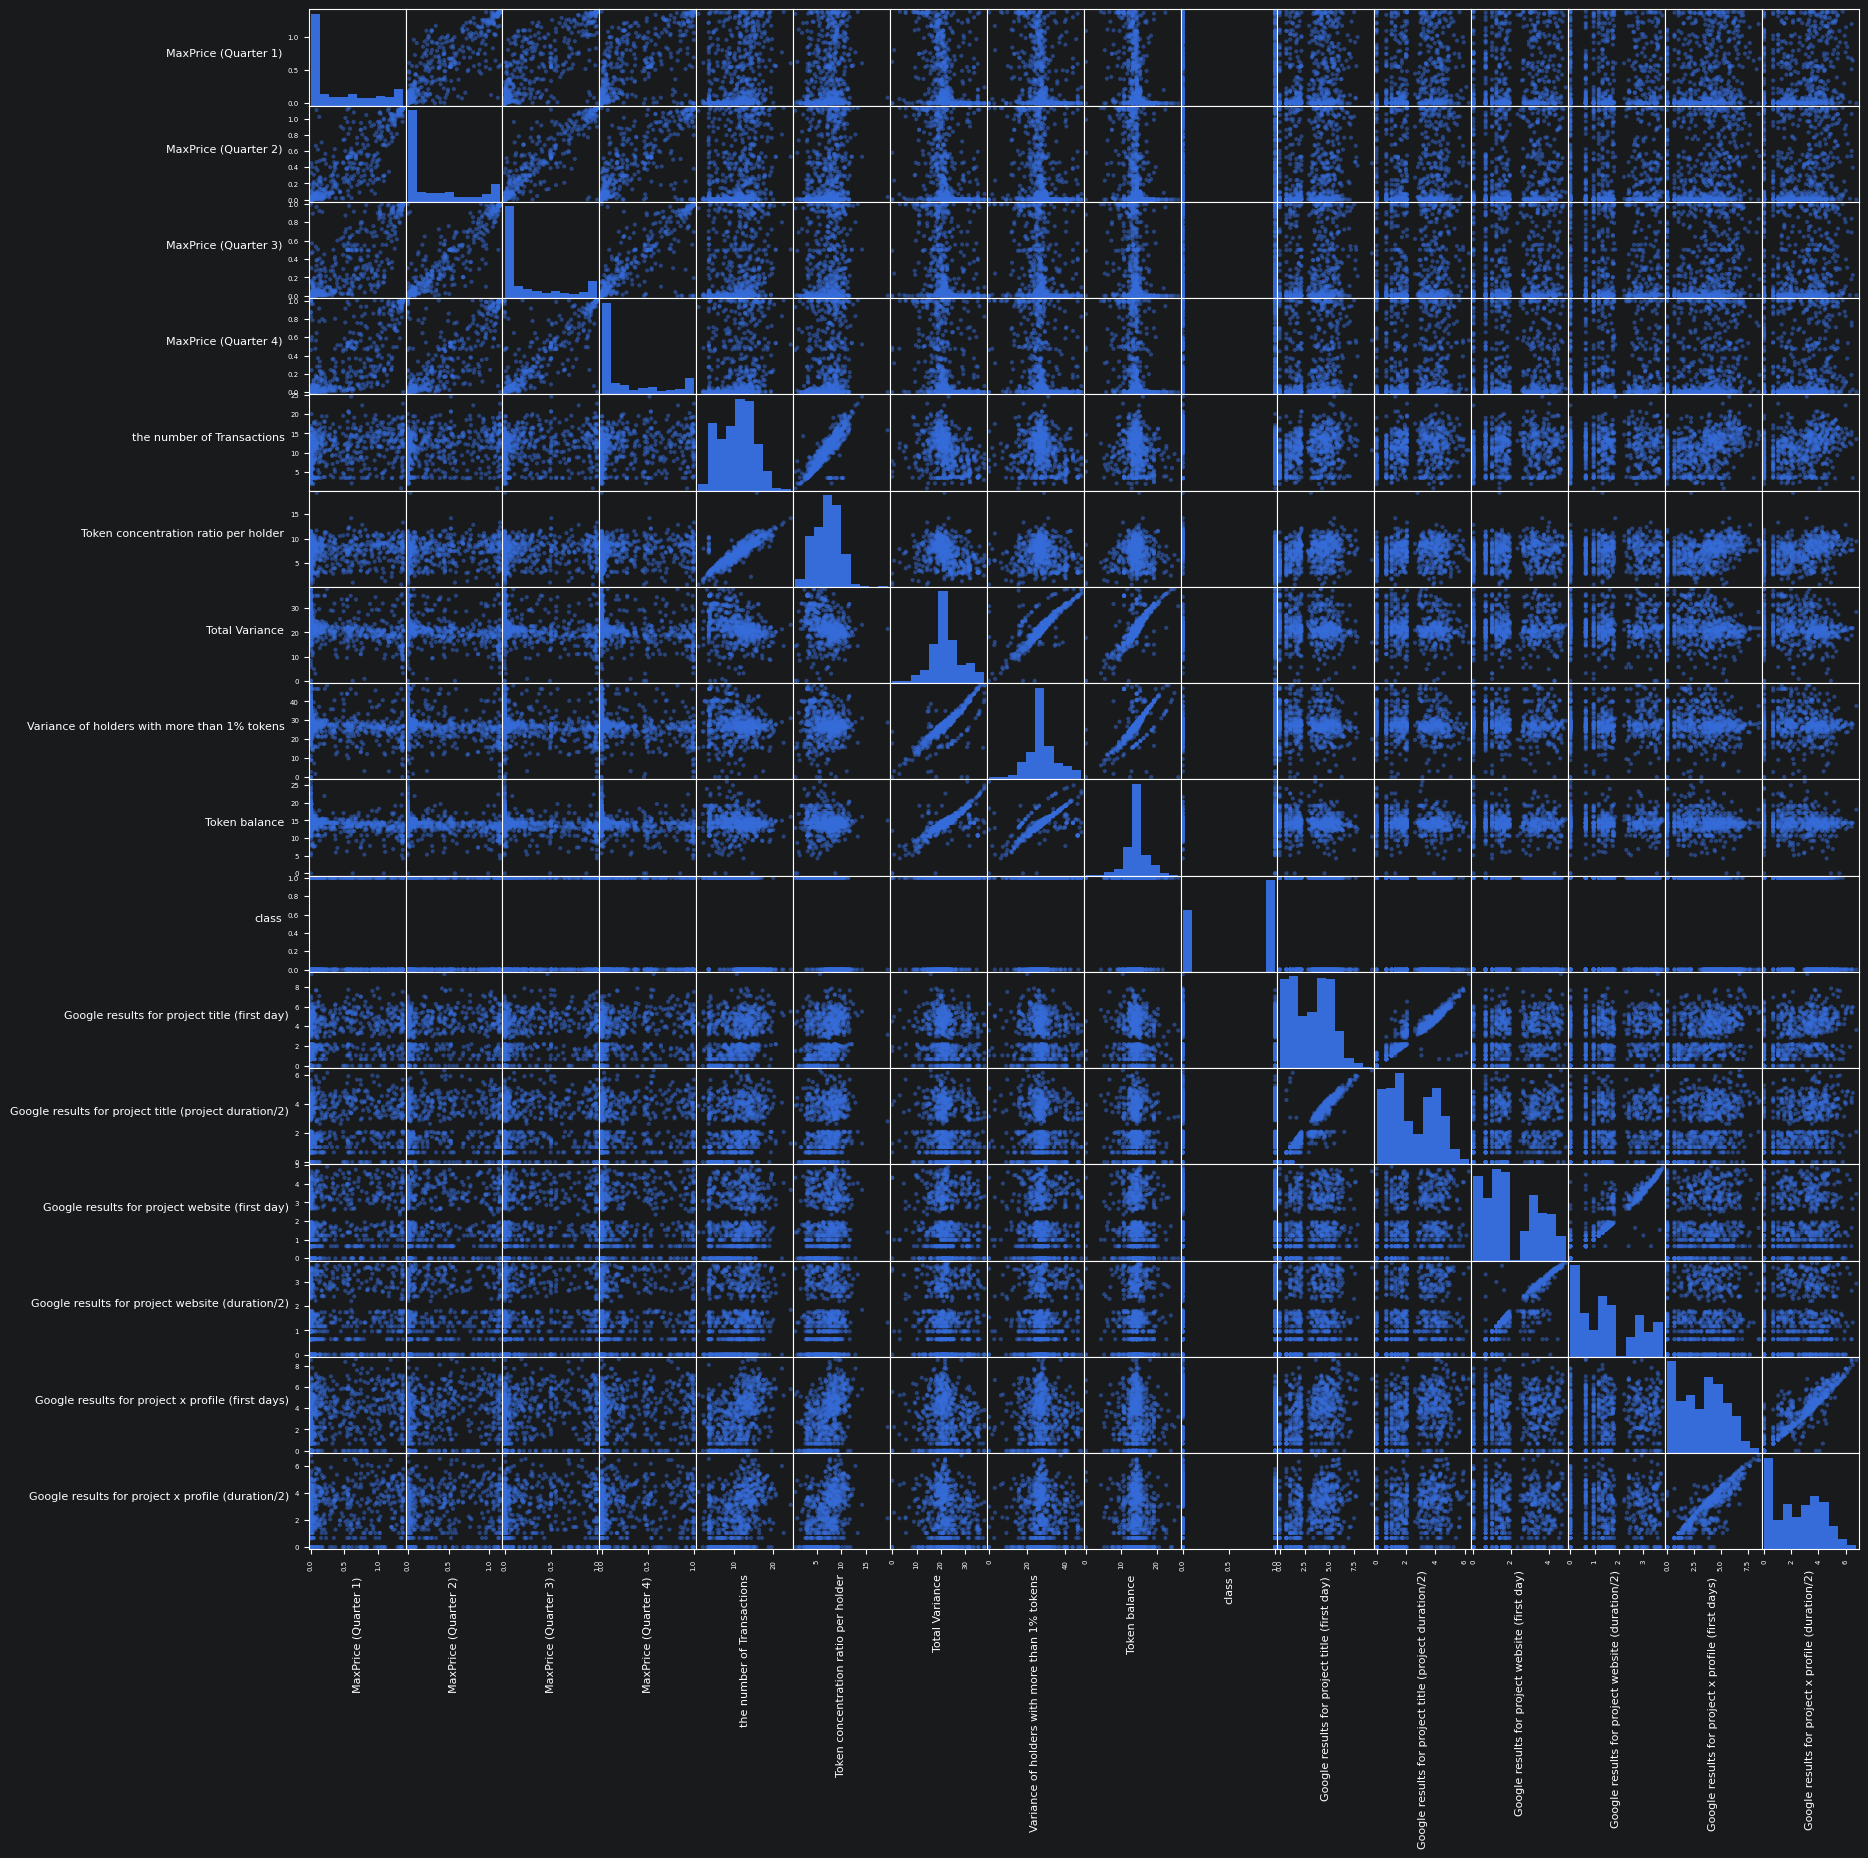

In [41]:
# Scatter plot Matrix after handling skew

# Reference: https://matplotlib.org/3.10.3/gallery/text_labels_and_annotations/align_ylabels.html

axes = pd.plotting.scatter_matrix(train_transformed[numeric_cols], figsize=(20, 20))

for ax_row in axes:
    for ax in ax_row:
        ax.xaxis.label.set_rotation(90)
        ax.yaxis.label.set_rotation(0)
        ax.xaxis.label.set_fontsize(8)
        ax.yaxis.label.set_fontsize(8)
        ax.tick_params(axis='both', labelsize=5)

        # Shift y labels left
        ax.yaxis.set_label_position("left")
        ax.yaxis.label.set_horizontalalignment('right')
        ax.yaxis.label.set_x(-0.2)

pyplot.show()

## Model specific pre-processing

##### Since models from different families will be trained on data, data requires some additional pre-processing depending on model trained. Some algorithms perform better on rescaled data (e.g. K-Nearest Neighbors or Linear regression), whereas others (like Random Forest) may degrade after rescaling. Model specific pre-processing will be handled in separate pipelines for particular models before training, and then all versions of data (after minimal pre-processing, after transformation and after specific pre-processing) will be used to train models and evaluate performance.

## Training models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


# Instantiate models that do not require scaling (tree/ensemble based)
def instantiate_unscaled_models():
    models = []
    models.append(('RandomForest', RandomForestClassifier(n_estimators=300, random_state=seed, n_jobs=-1)))
    models.append(('XGBoost', XGBClassifier(random_state=seed, eval_metric='logloss', n_jobs=-1)))
    return models


# Instantiate models that require scaling (distance/coefficient based)
def instantiate_scaled_models():
    models = []
    models.append(('LogisticRegression', Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(random_state=seed, max_iter=1000))
    ])))
    models.append(('LinearDiscriminantAnalysis', Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearDiscriminantAnalysis())
    ])))
    models.append(('KNeighbors', Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier())
    ])))
    models.append(('SVC', Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(probability=True, random_state=seed))
    ])))
    return models


# Combine both groups to instantiate all models for experimentation
def instantiate_all_models():
    return instantiate_unscaled_models() + instantiate_scaled_models()


# Fit a model, make predictions and print classification report and confusion matrix
def train_model_print_reports_and_matrix(name, model, X_train, Y_train, X_test, Y_test):
    model.fit(X_train, Y_train)
    predicted = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    print(f"\n{name} performance on test set:")
    print(classification_report(Y_test, predicted, digits=3))
    print(confusion_matrix(Y_test, predicted))
    print(f"Test ROC AUC: {roc_auc_score(Y_test, proba):.3f}")


# Assess a model with cross-validation
def assess_with_cross_val(name, model, kfold, X, Y):
    result = cross_validate(model, X, Y, cv=kfold, scoring=('accuracy', 'roc_auc', 'f1'))
    print(f"{name} mean accuracy {result['test_accuracy'].mean():.3f} (+/- {result['test_accuracy'].std():.3f})")
    print(f"{name} mean AUC {result['test_roc_auc'].mean():.3f} (+/- {result['test_roc_auc'].std():.3f})")
    print(f"{name} mean f1 {result['test_f1'].mean():.3f} (+/- {result['test_f1'].std():.3f})\n")

    return {
        'model': name,
        'accuracy_mean': result['test_accuracy'].mean(),
        'accuracy_std': result['test_accuracy'].std(),
        'roc_auc_mean': result['test_roc_auc'].mean(),
        'roc_auc_std': result['test_roc_auc'].std(),
        'f1_mean': result['test_f1'].mean(),
        'f1_std': result['test_f1'].std()
    }


In [ ]:
# Instantiating kfold object for future assessment
# TODO: assess whether I need it

from sklearn.model_selection import KFold

kfold = KFold(n_splits=10, random_state=seed, shuffle=True)

### Random Forest

##### Random Forest usually handles outliers and values with different scales well, and applying normalising or re-scaling techniques do not improve performance. Thus, Random Forest model will be trained on two versions of data: after minimal pre-processing and after transformation.

In [42]:
# Train and evaluate Random Forest algorithm on minimally pre-processed dataset (clipped, but with skew remaining)

# TODO: get rid of repetitive code, introduce some functions and nicely formatted comparative output

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

rf_minimal = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=-1,
    random_state=seed
)

rf_minimal.fit(X_train_minimal, Y_train_minimal)

Y_test_pred  = rf_minimal.predict(X_test_minimal)
Y_test_proba = rf_minimal.predict_proba(X_test_minimal)[:, 1]

print("Test classification report:\n")
print(classification_report(Y_test_minimal, Y_test_pred, digits=3))

test_auc = roc_auc_score(Y_test_minimal, Y_test_proba)
print(f"Test ROC AUC: {test_auc:.3f}")

Test classification report:

              precision    recall  f1-score   support

         0.0    0.92632   0.89796   0.91192        98
         1.0    0.93197   0.95139   0.94158       144

    accuracy                        0.92975       242
   macro avg    0.92914   0.92467   0.92675       242
weighted avg    0.92968   0.92975   0.92957       242

Test ROC AUC: 0.976


In [43]:
# Train and evaluate Random Forest algorithm on transformed dataset

rf_transformed = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=-1,
    random_state=seed
)

rf_transformed.fit(X_train_transformed, Y_train_transformed)

Y_test_pred  = rf_transformed.predict(X_test_transformed)
Y_test_proba = rf_transformed.predict_proba(X_test_transformed)[:, 1]

print("Test classification report:\n")
print(classification_report(Y_test_transformed, Y_test_pred, digits=3))

test_auc = roc_auc_score(Y_test_transformed, Y_test_proba)
print(f"Test ROC AUC: {test_auc:.3f}")

Test classification report:

              precision    recall  f1-score   support

         0.0    0.92632   0.89796   0.91192        98
         1.0    0.93197   0.95139   0.94158       144

    accuracy                        0.92975       242
   macro avg    0.92914   0.92467   0.92675       242
weighted avg    0.92968   0.92975   0.92957       242

Test ROC AUC: 0.976


In [44]:
proba_minimal = rf_minimal.predict_proba(X_test_minimal)[:, 1]
proba_transformed = rf_transformed.predict_proba(X_test_transformed)[:, 1]

print("predict_proba allclose?", np.allclose(proba_minimal, proba_transformed, rtol=1e-8, atol=1e-10))
print("Max abs proba difference:", np.abs(proba_minimal - proba_transformed).max())
print("Rows with proba diff > 1e-6:", np.sum(np.abs(proba_minimal - proba_transformed) > 1e-6))

predict_proba allclose? False
Max abs proba difference: 0.05666666666666664
Rows with proba diff > 1e-6: 201


In [45]:
import pandas as pd

feature_names_minimal = train_minimal.drop(columns=['class']).columns
feature_names_transformed = train_transformed.drop(columns=['class']).columns

importances_df = pd.DataFrame({
    'feature': feature_names_minimal,
    'importance_minimal': rf_minimal.feature_importances_,
    'importance_transformed': rf_transformed.feature_importances_
})
importances_df['diff'] = importances_df['importance_minimal'] - importances_df['importance_transformed']
print(importances_df.sort_values('diff', key=abs, ascending=False).head(15))

                                              feature  importance_minimal  \
1                                MaxPrice (Quarter 2)            0.054348   
2                                MaxPrice (Quarter 3)            0.050310   
3                                MaxPrice (Quarter 4)            0.045392   
13  Google results for project x profile (first days)            0.114782   
11     Google results for project website (first day)            0.028344   
17                                     Blockchain_ETH            0.008147   
5                Token concentration ratio per holder            0.156994   
9        Google results for project title (first day)            0.027826   
4                          the number of Transactions            0.181732   
0                                MaxPrice (Quarter 1)            0.058656   
8                                       Token balance            0.028309   
6                                      Total Variance            0.047532   

## Feature importance assessment

In [46]:
# TODO: assess feature importance after training models to understand what features were most predictive